# Sub-Task 1: Fascia Detection — Architecture Comparison

Trains and compares **5 segmentation architectures** on ultrasound fascia detection:
- **U-Net (ResNet-50)** — CNN baseline with skip connections
- **U-Net++ (EfficientNet-B4)** — Nested dense skip connections
- **Attention U-Net (ResNet-50)** — Attention gates on skip connections
- **SegFormer-B5** — Pure transformer, no positional encoding
- **SwinUNet** — Swin Transformer encoder + U-Net decoder (medical-focused)

**Output mask classes:**
- `0` = Below fascia (deep region)
- `1` = Fascia band
- `2` = Above fascia (superficial region)

**Ground truth extraction:** Yellow pixels from Folder 3 (Simple Annotated) — yellow = fascia only in that folder.

In [1]:
# ── GPU / Environment Check ───────────────────────────────────────────────────
import subprocess, torch

print('=' * 65)
print('ENVIRONMENT')
print('=' * 65)
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()} | version {torch.version.cuda}')
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f'GPU {i}    : {p.name}  |  {p.total_memory/1024**3:.1f} GB VRAM')

print()
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout)

ENVIRONMENT
PyTorch  : 2.10.0+cu128
CUDA     : True | version 12.8
GPU 0    : NVIDIA GeForce RTX 5090  |  31.8 GB VRAM

Tue May 26 15:37:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0  On |                  N/A |
|  0%   31C    P8             13W /  575W |     930MiB /  32607MiB |      0%      Default |
|                   

In [2]:
#! pip install torch==2.10.0+cu128 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [3]:
! python -c "import torch; print(torch.__version__); print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))"

2.10.0+cu128
True
NVIDIA GeForce RTX 5090


In [4]:
# ── GPU / Environment Check ───────────────────────────────────────────────────
import subprocess, torch

print('=' * 65)
print('ENVIRONMENT')
print('=' * 65)
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()} | version {torch.version.cuda}')
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f'GPU {i}    : {p.name}  |  {p.total_memory/1024**3:.1f} GB VRAM')

print()
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout)

ENVIRONMENT
PyTorch  : 2.10.0+cu128
CUDA     : True | version 12.8
GPU 0    : NVIDIA GeForce RTX 5090  |  31.8 GB VRAM

Tue May 26 15:37:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0  On |                  N/A |
|  0%   31C    P8             18W /  575W |     923MiB /  32607MiB |      0%      Default |
|                   

In [5]:
"""
# ── Install Dependencies ──────────────────────────────────────────────────────
import subprocess, sys

pkgs = [
    'segmentation-models-pytorch',
    'transformers>=4.40.0',
    'timm>=1.0.0',
    'albumentations>=1.4.0',
    'opencv-python-headless',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tqdm',
    'pandas',
    'scipy',
    'torchmetrics',
]
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=True)
print('All packages ready.')
"""

"\n# ── Install Dependencies ──────────────────────────────────────────────────────\nimport subprocess, sys\n\npkgs = [\n    'segmentation-models-pytorch',\n    'transformers>=4.40.0',\n    'timm>=1.0.0',\n    'albumentations>=1.4.0',\n    'opencv-python-headless',\n    'matplotlib',\n    'seaborn',\n    'scikit-learn',\n    'tqdm',\n    'pandas',\n    'scipy',\n    'torchmetrics',\n]\nfor p in pkgs:\n    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=True)\nprint('All packages ready.')\n"

**Please Restart Kernel if running for the first time**

In [6]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, cv2, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
from scipy.ndimage import label as scipy_label
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
import timm
from transformers import (
    SegformerForSemanticSegmentation,
    SegformerConfig,
)
from torchmetrics import JaccardIndex #, Dice

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [7]:
# ── Global Config ─────────────────────────────────────────────────────────────
class CFG:
    # Paths  (notebook lives in Task_3/notebooks/  →  data is one level up)
    ROOT        = Path('../')
    RAW_DIR     =  "Data/1-Videos" #ROOT / 'Data' / '1-Videos'
    ANN_DIR     =  "Data/3-Simple_Annotated_Videos" #ROOT / 'Data' / '3-Simple_Annotated_Videos'
    OUT_DIR     =  "output/fascia" #ROOT / 'output' / 'fascia'
    FRAMES_DIR  = OUT_DIR + '/frames'
    MASKS_DIR   = OUT_DIR + '/masks'
    CKPT_DIR    = OUT_DIR + '/checkpoints'
    PLOT_DIR    = OUT_DIR + '/plots'

    # Image
    IMG_SIZE    = 384          # all models use 384x384
    NUM_CLASSES = 3

    # Training
    EPOCHS      = 60
    BATCH_SIZE  = 48           # reduce to 16 if OOM
    LR          = 3e-4
    WEIGHT_DECAY= 1e-4
    NUM_WORKERS = 8
    SEED        = 42
    PATIENCE    = 5           # early stopping

    # Which videos go to validation (held-out, most different device/anatomy)
    VAL_VIDEOS  = ['Knee-Ankle-Seg1']

    # Class colours for visualisation
    CLS_COLORS  = {
        0: (0.15, 0.47, 0.71),   # blue  – below fascia
        1: (1.00, 0.85, 0.00),   # yellow – fascia band
        2: (0.17, 0.63, 0.17),   # green – above fascia
    }
    CLS_NAMES   = {0: 'Below fascia', 1: 'Fascia band', 2: 'Above fascia'}


# Create output dirs
for d in [CFG.FRAMES_DIR, CFG.MASKS_DIR, CFG.CKPT_DIR, CFG.PLOT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
print('Config ready. Output at:', Path(CFG.OUT_DIR).resolve())


Config ready. Output at: /home/krish/vein_detection_task_3_training/output/fascia


---
## 1  Data Extraction
Extract paired (frame, mask) from the processed and simple-annotated videos.

**Yellow detection** (HSV): H 18–42 · S > 70 · V > 70 → fascia lines only in Folder 3.

In [8]:
# ── Mask Extraction Utilities ─────────────────────────────────────────────────
def detect_yellow_mask(bgr_frame):
    """Return binary mask of yellow pixels (fascia annotation lines)."""
    hsv = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2HSV)
    # Primary yellow range
    m1 = cv2.inRange(hsv, np.array([18, 70, 70]),  np.array([42, 255, 255]))
    # Exclude green (vein circles) that may bleed
    green = cv2.inRange(hsv, np.array([46, 60, 60]), np.array([90, 255, 255]))
    mask = cv2.bitwise_and(m1, cv2.bitwise_not(green))
    # Clean tiny noise
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    return mask


def mask_to_3class(yellow_mask):
    """
    Column-wise: find topmost and bottommost yellow pixel.
    0 = below fascia, 1 = fascia band, 2 = above fascia.
    Returns (mask_array, has_fascia_flag).
    """
    h, w = yellow_mask.shape
    out = np.zeros((h, w), dtype=np.uint8)
    has_fascia = False

    for x in range(w):
        col = yellow_mask[:, x]
        ys  = np.where(col > 0)[0]
        if len(ys) >= 2:
            y_top = int(ys.min())
            y_bot = int(ys.max())
            out[:y_top, x]          = 2   # above
            out[y_top:y_bot + 1, x] = 1   # band
            # below stays 0
            has_fascia = True
        elif len(ys) == 1:
            out[:int(ys[0]), x] = 2
            has_fascia = True

    return out, has_fascia


def validate_mask(mask):
    """Reject masks where fascia band is < 2 px tall on average (bad frame)."""
    band_cols = (mask == 1).sum(axis=0)  # pixels in class 1 per column
    return float(band_cols[band_cols > 0].mean()) > 2 if band_cols.any() else False


print('Mask utilities defined.')

Mask utilities defined.


**Getting Data Ready**

In [ ]:
# ── Extract All Frames + Masks ────────────────────────────────────────────────
SAMPLE_STRIDE = 3

# Convert string paths to Path objects
RAW_DIR = Path(CFG.RAW_DIR)
ANN_DIR = Path(CFG.ANN_DIR)

metadata = []

raw_vids = sorted(RAW_DIR.glob('*.mp4')) + sorted(RAW_DIR.glob('*.MP4'))
print(f'Found {len(raw_vids)} videos in processed folder.')

for raw_path in raw_vids:
    stem     = raw_path.stem
    ann_path = ANN_DIR / raw_path.name
    if not ann_path.exists():
        ann_path = ANN_DIR / (raw_path.stem + '.mp4')
    if not ann_path.exists():
        print(f'  [SKIP] no annotated counterpart for {raw_path.name}'); continue

    cap_raw = cv2.VideoCapture(str(raw_path))
    cap_ann = cv2.VideoCapture(str(ann_path))
    total   = int(cap_raw.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'  Processing {stem}  ({total} frames) …')

    frame_dir = Path(CFG.FRAMES_DIR) / stem
    mask_dir  = Path(CFG.MASKS_DIR)  / stem
    frame_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    fi = 0
    saved = 0
    while True:
        ret_r, frame = cap_raw.read()
        ret_a, ann   = cap_ann.read()
        if not ret_r or not ret_a:
            break

        if fi % SAMPLE_STRIDE != 0:
            fi += 1
            continue

        sz    = (CFG.IMG_SIZE, CFG.IMG_SIZE)
        frame = cv2.resize(frame, sz)
        ann   = cv2.resize(ann,   sz)

        ymask           = detect_yellow_mask(ann)
        seg_mask, has_f = mask_to_3class(ymask)
        valid           = validate_mask(seg_mask) if has_f else False

        fp = frame_dir / f'{fi:05d}.png'
        mp = mask_dir  / f'{fi:05d}.png'
        cv2.imwrite(str(fp), frame)
        cv2.imwrite(str(mp), seg_mask)

        metadata.append({
            'frame_path': str(fp),
            'mask_path':  str(mp),
            'video':      stem,
            'frame_idx':  fi,
            'has_fascia': has_f,
            'valid_mask': valid,
        })
        saved += 1
        fi += 1

    cap_raw.release()
    cap_ann.release()
    print(f'    Saved {saved} frames.')

df = pd.DataFrame(metadata)
df.to_csv(Path(CFG.OUT_DIR) / 'metadata.csv', index=False)
print(f'\nTotal frames extracted : {len(df)}')
print(f'Frames with fascia     : {df.has_fascia.sum()}')
print(f'Valid masks            : {df.valid_mask.sum()}')
print(df.groupby('video')[['has_fascia','valid_mask']].sum())

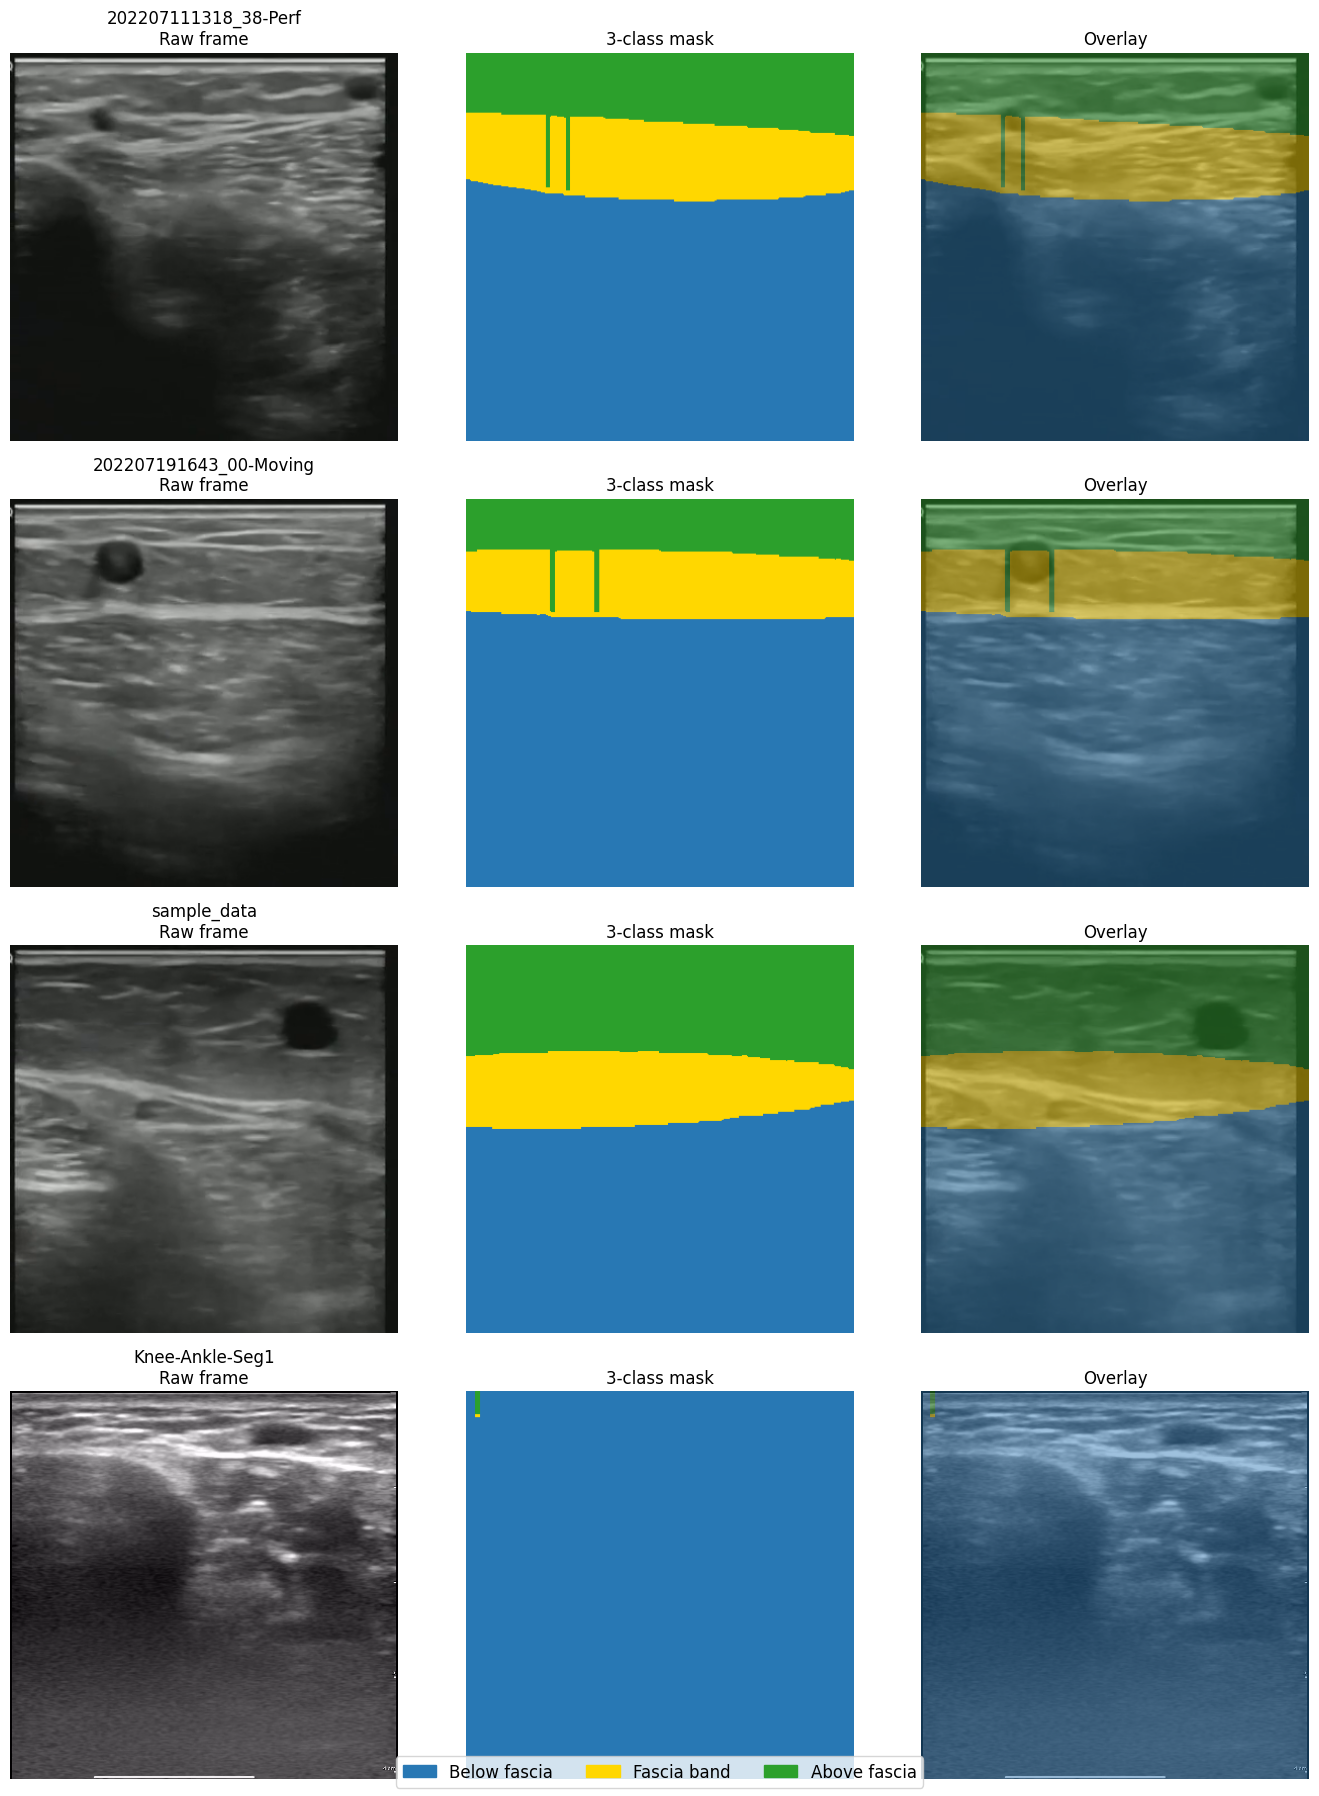

In [10]:
def colorise_mask(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, col in {0:(40,120,180), 1:(255,215,0), 2:(44,160,44)}.items():
        rgb[mask == cls] = col
    return rgb

def overlay_mask(frame_bgr, mask, alpha=0.45):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return (frame_rgb*(1-alpha) + colorise_mask(mask)*alpha).astype(np.uint8)

# Pick middle frame per video — avoids groupby.apply index quirks
valid_df = df[df['valid_mask']].reset_index(drop=True)
sample_rows = []
for vid in valid_df['video'].unique():
    grp = valid_df[valid_df['video'] == vid]
    sample_rows.append(grp.iloc[len(grp) // 2])

n = len(sample_rows)
fig, axes = plt.subplots(n, 3, figsize=(14, 4.5 * n))
if n == 1:
    axes = axes[np.newaxis]

for i, row in enumerate(sample_rows):
    frame = cv2.imread(row['frame_path'])
    mask  = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
    axes[i, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"{row['video']}\nRaw frame")
    axes[i, 1].imshow(colorise_mask(mask))
    axes[i, 1].set_title('3-class mask')
    axes[i, 2].imshow(overlay_mask(frame, mask))
    axes[i, 2].set_title('Overlay')
    for ax in axes[i]:
        ax.axis('off')

patches = [mpatches.Patch(color=np.array(c)/255, label=lbl)
           for lbl, c in [('Below fascia',(40,120,180)),
                           ('Fascia band',(255,215,0)),
                           ('Above fascia',(44,160,44))]]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=12)
plt.tight_layout()
plt.savefig(Path(CFG.PLOT_DIR) / 'sample_frames_masks.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# Which video is the bad row?
print(sample_rows[1]['video'], sample_rows[1]['frame_path'])

# Look at the raw annotated frame (from 3-Simple_Annotated_Videos) for that frame index
import os
bad_row = sample_rows[1]
print(bad_row['video'], bad_row['frame_idx'])

# Also tighten the valid_mask filter — current threshold is >2px average band width
# How many valid frames does each video have?
print(df.groupby('video')[['has_fascia','valid_mask']].sum())

202207191643_00-Moving output/fascia/frames/202207191643_00-Moving/00774.png
202207191643_00-Moving 774
                        has_fascia  valid_mask
video                                         
202207111318_38-Perf           144         144
202207191643_00-Moving         462         462
202207221607_52-Long2            0           0
Knee-Ankle-Seg1                 28          28
sample_data                    320         320


Hue values of saturated pixels: [ 18  26  27  28  33  34  37  39  41  42  44  46  47  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  66  68  69  71  72  73  74  75
  76  80  81  84  87  88  90  94 100 105 113 114 120 129 131 137 138 140
 146 155 177]


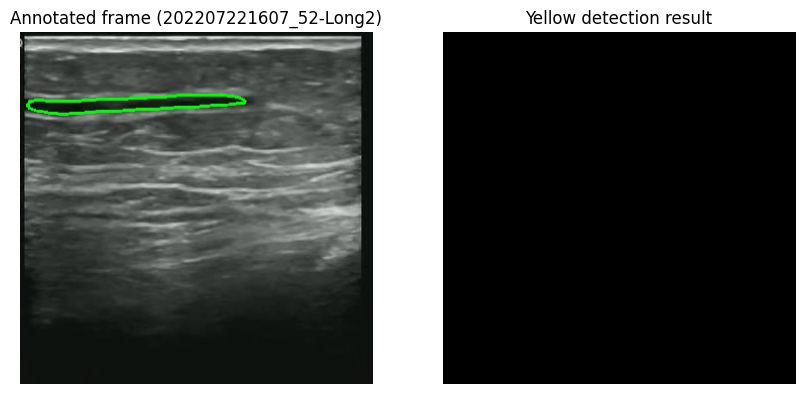

In [12]:
import cv2
import numpy as np

# Check a few frames from the zero-valid video
ann_path = "Data/3-Simple_Annotated_Videos/202207221607_52-Long2.mp4"
cap = cv2.VideoCapture(ann_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()
cap.release()

if ret:
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    # Show what hues exist in the frame
    h_channel = hsv[:,:,0]
    s_channel = hsv[:,:,1]
    # Find bright/saturated pixels (likely annotations)
    bright_mask = s_channel > 80
    print("Hue values of saturated pixels:", np.unique(h_channel[bright_mask]))
    
    # Show the raw annotated frame
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title('Annotated frame (202207221607_52-Long2)')
    plt.axis('off')
    plt.subplot(1,2,2)
    # Current yellow mask
    yellow = cv2.inRange(hsv, np.array([18,70,70]), np.array([42,255,255]))
    plt.imshow(yellow, cmap='gray')
    plt.title('Yellow detection result')
    plt.axis('off')
    plt.show()

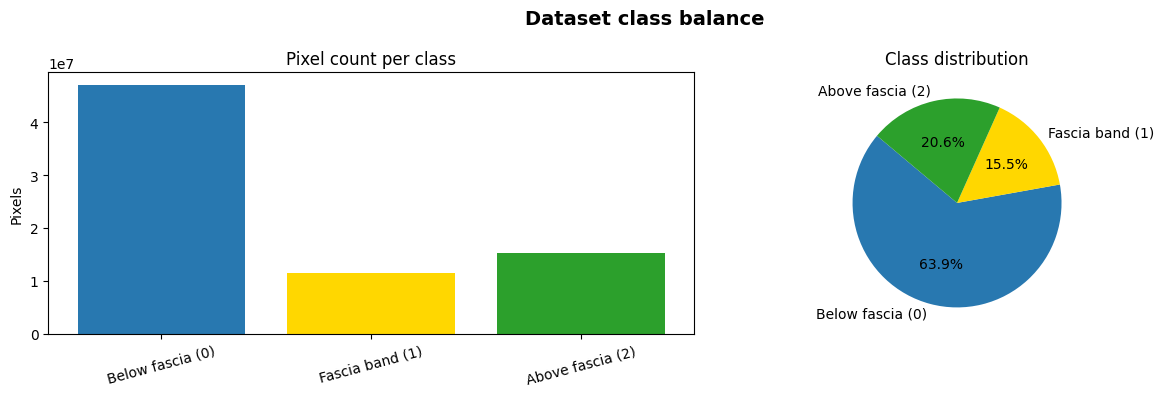

  Below fascia (0): 47,137,596 px  (63.9%)
  Fascia band (1): 11,413,196 px  (15.5%)
  Above fascia (2): 15,177,208 px  (20.6%)


In [13]:
sample_df  = df[df.valid_mask].sample(min(500, int(df.valid_mask.sum())), random_state=CFG.SEED)
class_counts = np.zeros(3, dtype=np.int64)
for _, row in sample_df.iterrows():
    m = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
    for c in range(3):
        class_counts[c] += (m == c).sum()

labels = ['Below fascia (0)', 'Fascia band (1)', 'Above fascia (2)']
colors = ['#2878b0', '#ffd700', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(labels, class_counts, color=colors)
axes[0].set_title('Pixel count per class'); axes[0].set_ylabel('Pixels')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(class_counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Class distribution')
plt.suptitle('Dataset class balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.PLOT_DIR) / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
for l, c in zip(labels, class_counts):
    print(f'  {l}: {c:>10,} px  ({100*c/class_counts.sum():.1f}%)')

---
## 2  Dataset & DataLoader

In [14]:
# ── Augmentation Pipelines ────────────────────────────────────────────────────
# Heavy augmentation is critical with only ~5 video clips

TRAIN_TRANSFORMS = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomResizedCrop(size=(CFG.IMG_SIZE, CFG.IMG_SIZE),
                        scale=(0.75, 1.0), ratio=(0.9, 1.1), p=0.4),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1),
        A.MultiplicativeNoise(multiplier=(0.85, 1.15), p=1),
        A.ISONoise(p=1),
    ], p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1),
        A.MedianBlur(blur_limit=3, p=1),
        A.MotionBlur(blur_limit=5, p=1),
    ], p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.25, p=0.6),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
    A.ElasticTransform(alpha=50, sigma=5, p=0.3),
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(10, 20),
                    hole_width_range=(10, 20), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

VAL_TRANSFORMS = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print('Augmentation pipelines defined.')

Augmentation pipelines defined.


In [15]:
# ── Dataset Class ─────────────────────────────────────────────────────────────
class FasciaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        # Keep only valid frames with proper fascia masks
        self.df        = dataframe[dataframe.valid_mask].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row.frame_path)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE).astype(np.int64)

        if self.transform:
            aug  = self.transform(image=img, mask=mask.astype(np.uint8))
            img  = aug['image']               # (3, H, W) float tensor
            mask = aug['mask'].long()         # (H, W) int64 tensor

        return img, mask


# ── Train / Val Split (by video, not by frame) ────────────────────────────────
val_df   = df[df.video.isin(CFG.VAL_VIDEOS)]
train_df = df[~df.video.isin(CFG.VAL_VIDEOS)]

train_ds = FasciaDataset(train_df, TRAIN_TRANSFORMS)
val_ds   = FasciaDataset(val_df,   VAL_TRANSFORMS)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

print(f'Train samples : {len(train_ds):>5}  from videos: {train_df.video.unique().tolist()}')
print(f'Val   samples : {len(val_ds):>5}  from videos: {val_df.video.unique().tolist()}')
print(f'Train batches : {len(train_loader)} | Val batches: {len(val_loader)}')

Train samples :   926  from videos: ['202207111318_38-Perf', '202207191643_00-Moving', '202207221607_52-Long2', 'sample_data']
Val   samples :    28  from videos: ['Knee-Ankle-Seg1']
Train batches : 19 | Val batches: 1


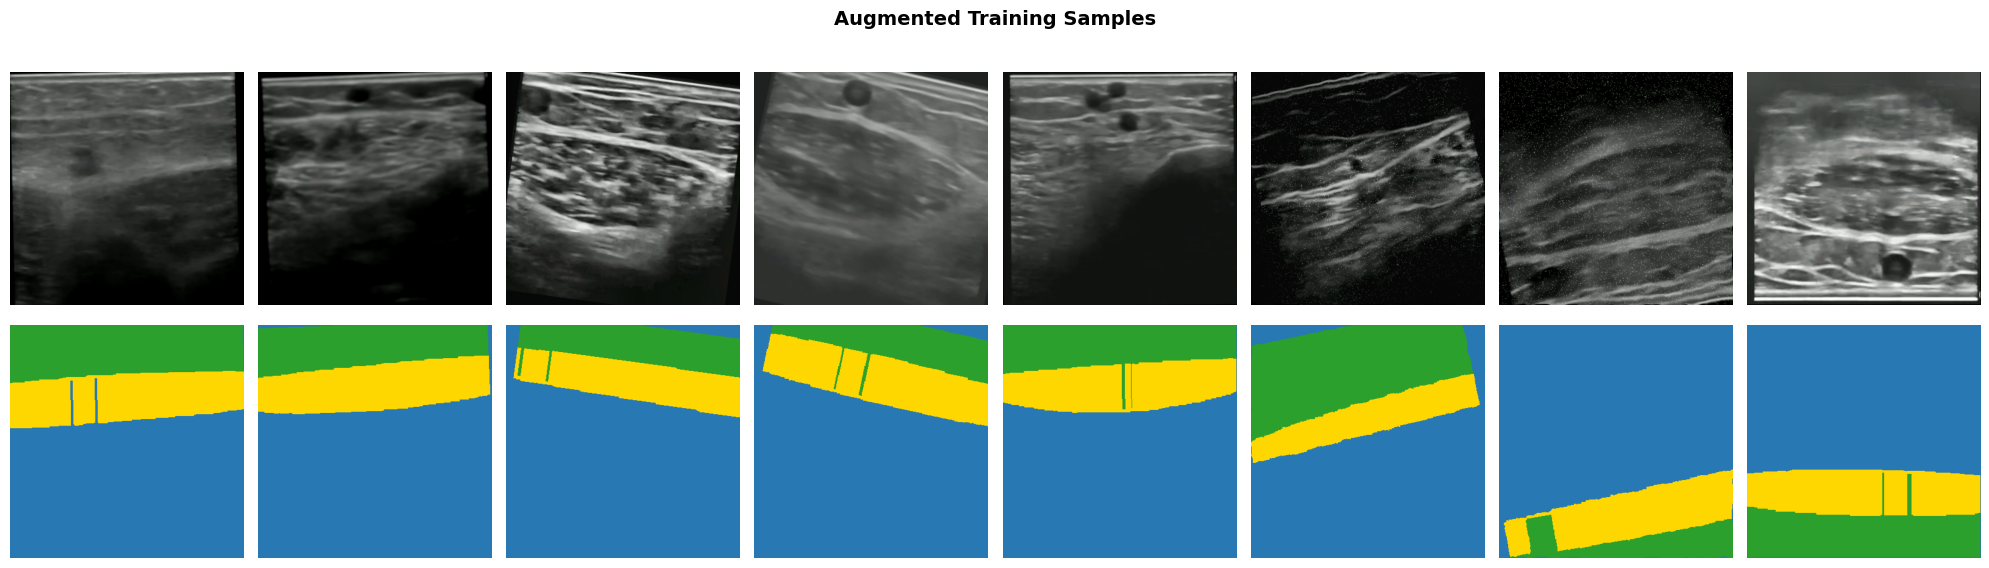

In [16]:
# ── Visualise Augmented Samples ───────────────────────────────────────────────
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denorm(t):
    """Denormalise tensor (3,H,W) → numpy uint8 RGB."""
    arr = t.permute(1, 2, 0).numpy()
    arr = (arr * STD + MEAN).clip(0, 1)
    return (arr * 255).astype(np.uint8)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 6))
batch_imgs, batch_masks = next(iter(train_loader))

for j in range(n_show):
    axes[0, j].imshow(denorm(batch_imgs[j]));          axes[0, j].axis('off')
    axes[1, j].imshow(colorise_mask(batch_masks[j].numpy())); axes[1, j].axis('off')
axes[0, 0].set_ylabel('Image', fontsize=12)
axes[1, 0].set_ylabel('Mask',  fontsize=12)
plt.suptitle('Augmented Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.PLOT_DIR) / 'augmented_samples.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3  Model Architectures
All models use ImageNet pre-trained weights. Final output: `(B, num_classes, H, W)`.

In [17]:
# ── Shared Helper Blocks ──────────────────────────────────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print('Helper blocks defined.')

Helper blocks defined.


In [18]:
# ── Model 1: U-Net (ResNet-50) ────────────────────────────────────────────────
def build_unet_resnet50():
    model = smp.Unet(
        encoder_name    = 'resnet50',
        encoder_weights = 'imagenet',
        in_channels     = 3,
        classes         = CFG.NUM_CLASSES,
        activation      = None,   # raw logits, loss handles softmax
    )
    return model

m1 = build_unet_resnet50()
t, tr = count_params(m1)
print(f'[1] U-Net ResNet-50     | Total: {t/1e6:.1f}M | Trainable: {tr/1e6:.1f}M')

[1] U-Net ResNet-50     | Total: 32.5M | Trainable: 32.5M


In [19]:
# ── Model 2: U-Net++ (EfficientNet-B4) ───────────────────────────────────────
def build_unetpp_efficientnet():
    model = smp.UnetPlusPlus(
        encoder_name    = 'efficientnet-b4',
        encoder_weights = 'imagenet',
        in_channels     = 3,
        classes         = CFG.NUM_CLASSES,
        activation      = None,
    )
    return model

m2 = build_unetpp_efficientnet()
t, tr = count_params(m2)
print(f'[2] U-Net++ EfficientB4 | Total: {t/1e6:.1f}M | Trainable: {tr/1e6:.1f}M')

[2] U-Net++ EfficientB4 | Total: 20.8M | Trainable: 20.8M


In [20]:
# ── Model 3: Attention U-Net (ResNet-50) ──────────────────────────────────────
def build_att_unet():
    model = smp.Unet(
        encoder_name     = 'resnet50',
        encoder_weights  = 'imagenet',
        decoder_attention_type = 'scse',   # Squeeze-Excitation channel + spatial
        in_channels      = 3,
        classes          = CFG.NUM_CLASSES,
        activation       = None,
    )
    return model

m3 = build_att_unet()
t, tr = count_params(m3)
print(f'[3] Att U-Net ResNet-50 | Total: {t/1e6:.1f}M | Trainable: {tr/1e6:.1f}M')

[3] Att U-Net ResNet-50 | Total: 33.8M | Trainable: 33.8M


In [21]:
import os
from pathlib import Path

os.environ['HF_TOKEN'] = ''
os.environ['HUGGING_FACE_HUB_TOKEN'] = ''

for p in [Path.home() / '.cache' / 'huggingface' / 'token',
          Path.home() / '.huggingface' / 'token']:
    if p.exists():
        p.unlink()
        print(f"Deleted: {p}")

print("Token cleared — re-run the model cells now")

Token cleared — re-run the model cells now


In [22]:
class SegFormerWrapper(nn.Module):
    def __init__(self, num_classes=3, img_size=384):
        super().__init__()
        self.img_size = img_size
        cfg = SegformerConfig.from_pretrained('nvidia/mit-b5', token=False)
        cfg.num_labels = num_classes
        cfg.id2label   = {i: str(i) for i in range(num_classes)}
        cfg.label2id   = {str(i): i for i in range(num_classes)}
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            'nvidia/mit-b5',
            config=cfg,
            ignore_mismatched_sizes=True,
            token=False,
        )

    def forward(self, x):
        out    = self.model(pixel_values=x)
        logits = out.logits
        return F.interpolate(logits,
                             size=(self.img_size, self.img_size),
                             mode='bilinear', align_corners=False)


In [23]:
# ── Model 5: SwinUNet (Swin-Base encoder + U-Net decoder) ─────────────────────
# Uses timm's Swin-Base pretrained at 384×384 as encoder,
# with a custom multi-scale U-Net decoder for full-resolution output.

class SwinUNetDecoder(nn.Module):
    def __init__(self, enc_channels, num_classes):
        super().__init__()
        c = enc_channels   # [128, 256, 512, 1024] for swin_base
        self.up3 = ConvBnRelu(c[3] + c[2], c[2])
        self.up2 = ConvBnRelu(c[2] + c[1], c[1])
        self.up1 = ConvBnRelu(c[1] + c[0], c[0])
        self.up0 = ConvBnRelu(c[0],         64)
        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, feats):
        # feats: list of (B, H_i, W_i, C_i) from timm Swin — convert to NCHW
        f = [x.permute(0, 3, 1, 2).contiguous() for x in feats]
        # f[0]: stride-4, f[1]: stride-8, f[2]: stride-16, f[3]: stride-32

        x = F.interpolate(f[3], size=f[2].shape[2:], mode='bilinear', align_corners=False)
        x = self.up3(torch.cat([x, f[2]], dim=1))

        x = F.interpolate(x, size=f[1].shape[2:], mode='bilinear', align_corners=False)
        x = self.up2(torch.cat([x, f[1]], dim=1))

        x = F.interpolate(x, size=f[0].shape[2:], mode='bilinear', align_corners=False)
        x = self.up1(torch.cat([x, f[0]], dim=1))

        # Upsample from stride-4 back to original resolution
        x = F.interpolate(x, scale_factor=4, mode='bilinear', align_corners=False)
        x = self.up0(x)
        return self.head(x)


class SwinUNet(nn.Module):
    def __init__(self, num_classes=3, img_size=384):
        super().__init__()
        # swin_base_patch4_window12_384 is pretrained on ImageNet-22K at 384×384
        self.encoder = timm.create_model(
            'swin_base_patch4_window12_384',
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        enc_channels = [128, 256, 512, 1024]   # swin_base channel widths
        self.decoder  = SwinUNetDecoder(enc_channels, num_classes)

    def forward(self, x):
        feats = self.encoder(x)   # list of NHWC tensors
        return self.decoder(feats)


m5 = SwinUNet(num_classes=CFG.NUM_CLASSES, img_size=CFG.IMG_SIZE)
t, tr = count_params(m5)
print(f'[5] SwinUNet (Swin-Base)| Total: {t/1e6:.1f}M | Trainable: {tr/1e6:.1f}M')

[5] SwinUNet (Swin-Base)| Total: 99.4M | Trainable: 99.4M


UNet-ResNet50            : output (2, 3, 384, 384)  |  32.5M params
UNet++-EffNetB4          : output (2, 3, 384, 384)  |  20.8M params
AttUNet-ResNet50         : output (2, 3, 384, 384)  |  33.8M params


Loading weights:   0%|          | 0/1156 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b5
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

SegFormer-B5             : output (2, 3, 384, 384)  |  84.6M params
SwinUNet                 : output (2, 3, 384, 384)  |  99.4M params


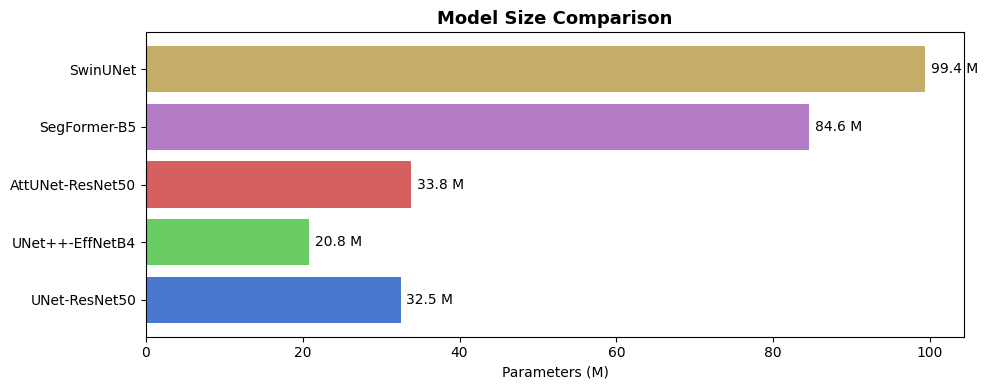

In [24]:
# ── Forward-pass smoke test + parameter comparison chart ──────────────────────
MODEL_REGISTRY = {
    'UNet-ResNet50':     build_unet_resnet50,
    'UNet++-EffNetB4':   build_unetpp_efficientnet,
    'AttUNet-ResNet50':  build_att_unet,
    'SegFormer-B5':      lambda: SegFormerWrapper(CFG.NUM_CLASSES, CFG.IMG_SIZE),
    'SwinUNet':          lambda: SwinUNet(CFG.NUM_CLASSES, CFG.IMG_SIZE),
}

dummy   = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
param_M = {}

for name, builder in MODEL_REGISTRY.items():
    m = builder().eval()
    with torch.no_grad():
        out = m(dummy)
    assert out.shape == (2, CFG.NUM_CLASSES, CFG.IMG_SIZE, CFG.IMG_SIZE), f'{name}: bad shape {out.shape}'
    total, _ = count_params(m)
    param_M[name] = total / 1e6
    print(f'{name:<25}: output {tuple(out.shape)}  |  {total/1e6:.1f}M params')
    del m

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(list(param_M.keys()), list(param_M.values()),
               color=['#4878cf','#6acc65','#d65f5f','#b47cc7','#c4ad66'])
ax.bar_label(bars, fmt='%.1f M', padding=4)
ax.set_xlabel('Parameters (M)')
ax.set_title('Model Size Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CFG.PLOT_DIR) / 'model_params.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4  Loss, Metrics & Trainer

In [26]:
def split_by_random(df, val_frac=0.2, seed=42):
    train_rows, val_rows = [], []
    for vid in df['video'].unique():
        grp = df[df['video'] == vid].sample(frac=1, random_state=seed).reset_index(drop=True)
        n_val = max(1, int(len(grp) * val_frac))
        val_rows.append(grp.iloc[:n_val])
        train_rows.append(grp.iloc[n_val:])
    return pd.concat(train_rows).reset_index(drop=True), pd.concat(val_rows).reset_index(drop=True)

valid_df = df[df['valid_mask']].reset_index(drop=True)
train_df, val_df = split_by_random(valid_df, val_frac=0.2)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print(val_df['video'].value_counts())

Train: 765 | Val: 189
video
202207191643_00-Moving    92
sample_data               64
202207111318_38-Perf      28
Knee-Ankle-Seg1            5
Name: count, dtype: int64


In [27]:
def compute_metrics(preds_list, targets_list, num_classes=3):
    all_preds   = torch.cat(preds_list,   dim=0).cpu()
    all_targets = torch.cat(targets_list, dim=0).cpu()

    jaccard = JaccardIndex(task='multiclass', num_classes=num_classes, average='none')
    per_iou = jaccard(all_preds, all_targets).numpy()

    # Manual Dice — avoids torchmetrics version API changes
    per_dice = np.zeros(num_classes, dtype=np.float32)
    for c in range(num_classes):
        p = (all_preds == c).float()
        t = (all_targets == c).float()
        per_dice[c] = (2 * (p * t).sum() / (p.sum() + t.sum() + 1e-6)).item()

    return {
        'iou_below':   float(per_iou[0]),
        'iou_fascia':  float(per_iou[1]),
        'iou_above':   float(per_iou[2]),
        'mIoU':        float(per_iou.mean()),
        'dice_fascia': float(per_dice[1]),
        'mean_dice':   float(per_dice.mean()),
    }

In [25]:
# ── Combined Loss: Dice + Cross-Entropy ───────────────────────────────────────
# Class weights to compensate for the thin fascia band being under-represented

class DiceCELoss(nn.Module):
    """
    Weighted sum of multi-class Dice loss and cross-entropy.
    Dice handles class imbalance; CE stabilises gradient early in training.
    """
    def __init__(self, num_classes=3, dice_w=0.6, ce_w=0.4,
                 class_weights=None, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.dice_w  = dice_w
        self.ce_w    = ce_w
        self.smooth  = smooth
        w = torch.tensor(class_weights, dtype=torch.float32) if class_weights else None
        self.ce = nn.CrossEntropyLoss(weight=w)

    def dice_loss(self, probs, targets):
        # probs : (B, C, H, W) after softmax
        # targets: (B, H, W) int
        B, C, H, W = probs.shape
        t_one_hot  = F.one_hot(targets, C).permute(0, 3, 1, 2).float()
        inter = (probs * t_one_hot).sum(dim=(0, 2, 3))
        union = probs.sum(dim=(0, 2, 3)) + t_one_hot.sum(dim=(0, 2, 3))
        dice  = (2. * inter + self.smooth) / (union + self.smooth)
        return 1. - dice.mean()

    def forward(self, logits, targets):
        probs   = torch.softmax(logits, dim=1)
        ce_loss = self.ce(logits, targets)
        dl      = self.dice_loss(probs, targets)
        return self.dice_w * dl + self.ce_w * ce_loss


# Upweight fascia band (class 1) — it's the minority class
#CRITERION = DiceCELoss(
#    num_classes   = CFG.NUM_CLASSES,
#   class_weights = [1.0, 3.0, 1.0],   # [below, fascia, above]
#).to(DEVICE)

CRITERION = DiceCELoss(
    num_classes   = CFG.NUM_CLASSES,
    class_weights = [1.0, 10.0, 1.0],
).to(DEVICE)
print('Loss function ready.')

Loss function ready.


In [26]:
# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics_old(preds_list, targets_list, num_classes=3):
    """
    preds_list  : list of (B, H, W) int tensors (argmax)
    targets_list: list of (B, H, W) int tensors
    Returns dict with per-class IoU, mean IoU, mean Dice.
    """
    all_preds   = torch.cat(preds_list,   dim=0).cpu()
    all_targets = torch.cat(targets_list, dim=0).cpu()

    jaccard = JaccardIndex(task='multiclass', num_classes=num_classes, average='none')
    dice    = Dice(num_classes=num_classes, average='none')

    per_iou  = jaccard(all_preds, all_targets).numpy()
    per_dice = dice(all_preds, all_targets).numpy()

    results = {
        'iou_below':  float(per_iou[0]),
        'iou_fascia': float(per_iou[1]),
        'iou_above':  float(per_iou[2]),
        'mIoU':       float(per_iou.mean()),
        'dice_fascia':float(per_dice[1]),
        'mean_dice':  float(per_dice.mean()),
    }
    return results

def compute_metrics(preds_list, targets_list, num_classes=3):
    _zero = {k: 0.0 for k in ['iou_below','iou_fascia','iou_above',
                                'mIoU','dice_fascia','mean_dice']}
    if not preds_list:
        return _zero
    try:
        all_preds   = torch.cat(preds_list,   dim=0).cpu()
        all_targets = torch.cat(targets_list, dim=0).cpu()

        jaccard = JaccardIndex(task='multiclass', num_classes=num_classes, average='none')
        per_iou = jaccard(all_preds, all_targets).detach().cpu().numpy()

        per_dice = np.zeros(num_classes, dtype=np.float32)
        for c in range(num_classes):
            p = (all_preds == c).float()
            t = (all_targets == c).float()
            per_dice[c] = (2*(p*t).sum() / (p.sum() + t.sum() + 1e-6)).item()

        return {
            'iou_below':   float(per_iou[0]),
            'iou_fascia':  float(per_iou[1]),
            'iou_above':   float(per_iou[2]),
            'mIoU':        float(per_iou.mean()),
            'dice_fascia': float(per_dice[1]),
            'mean_dice':   float(per_dice.mean()),
        }
    except Exception as e:
        import traceback; traceback.print_exc()
        return _zero



def boundary_f1(pred_mask, gt_mask, cls=1, dilation=2):
    """
    Boundary F1 for class `cls`.
    Extracts boundary pixels via morphological gradient, then computes F1.
    """
    import cv2 as _cv2
    k   = np.ones((3, 3), np.uint8)
    def boundary(m):
        m8 = (m == cls).astype(np.uint8) * 255
        return _cv2.dilate(m8, k, iterations=dilation) - _cv2.erode(m8, k, iterations=dilation)
    pb = boundary(pred_mask.numpy()) > 0
    gb = boundary(gt_mask.numpy())   > 0
    tp = (pb & gb).sum()
    prec = tp / (pb.sum() + 1e-6)
    rec  = tp / (gb.sum() + 1e-6)
    return 2 * prec * rec / (prec + rec + 1e-6)


print('Metrics ready.')

Metrics ready.


In [27]:
# Replace in your imports/config cell
AMP_DTYPE = torch.bfloat16

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32        = True
torch.backends.cudnn.enabled           = True   # retry with bfloat16
torch.backends.cudnn.benchmark         = True

In [31]:
# ── Trainer Class ─────────────────────────────────────────────────────────────
class Trainer:
    def __init__(self, model, name, epochs=CFG.EPOCHS, lr=CFG.LR):
        self.model = model.to(DEVICE) #torch.compile(model.to(DEVICE))   # compile for speed
        self.name   = name
        self.epochs = epochs
        # bfloat16 doesn't need GradScaler but keeping it is harmless
        self.scaler = GradScaler() if AMP_DTYPE == torch.float16 else None

        if isinstance(model, SegFormerWrapper):
            params = [
                {'params': model.model.segformer.parameters(),   'lr': lr * 0.1},
                {'params': model.model.decode_head.parameters(), 'lr': lr},
            ]
        else:
            params = model.parameters()

        self.optim = torch.optim.AdamW(params, lr=lr, weight_decay=CFG.WEIGHT_DECAY)
        self.sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                         self.optim, T_max=epochs, eta_min=1e-6)

        self.history          = defaultdict(list)
        self.best_miou        = 0.0
        self.patience_counter = 0
        self.ckpt_path        = Path(CFG.CKPT_DIR) / f'{name}_best.pth'

    def _run_epoch(self, loader, train=True):
        self.model.train() if train else self.model.eval()
        running_loss = 0.0
        all_preds, all_targets = [], []

        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for imgs, masks in loader:
                imgs  = imgs.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)

                with torch.autocast('cuda', dtype=AMP_DTYPE):
                    logits = self.model(imgs)
                    loss   = CRITERION(logits, masks)

                if train:
                    self.optim.zero_grad(set_to_none=True)
                    if self.scaler:
                        self.scaler.scale(loss).backward()
                        self.scaler.unscale_(self.optim)
                        nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                        self.scaler.step(self.optim)
                        self.scaler.update()
                    else:
                        loss.backward()
                        nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                        self.optim.step()

                running_loss += loss.item()
                preds = logits.argmax(dim=1).cpu()
                all_preds.append(preds)
                all_targets.append(masks.cpu())

        avg_loss = running_loss / len(loader)
        metrics  = compute_metrics(all_preds, all_targets)
        return avg_loss, metrics

    def fit(self, train_loader, val_loader):
        print(f'\n{"═"*60}')
        print(f'  Training: {self.name}')
        print(f'{"═"*60}')

        for epoch in range(1, self.epochs + 1):
            t0 = time.time()
            tr_loss, tr_m = self._run_epoch(train_loader, train=True)
            va_loss, va_m = self._run_epoch(val_loader,   train=False)
            self.sched.step()

            self.history['tr_loss'].append(tr_loss)
            self.history['va_loss'].append(va_loss)
            for k, v in va_m.items():
                self.history[f'va_{k}'].append(v)
            for k, v in tr_m.items():
                self.history[f'tr_{k}'].append(v)

            miou = va_m['mIoU']
            dt   = time.time() - t0
            print(f'  Ep {epoch:3d}/{self.epochs}  '
                  f'loss {tr_loss:.4f}/{va_loss:.4f}  '
                  f'mIoU {tr_m["mIoU"]:.4f}/{miou:.4f}  '
                  f'FasciaDice {va_m["dice_fascia"]:.4f}  '
                  f'[{dt:.1f}s]')

            if miou > self.best_miou:
                self.best_miou = miou
                torch.save(self.model.state_dict(), self.ckpt_path)
                self.patience_counter = 0
                print(f'    ✓ New best mIoU: {miou:.4f} — saved.')
            else:
                self.patience_counter += 1
                if self.patience_counter >= CFG.PATIENCE:
                    print(f'  Early stopping at epoch {epoch}.')
                    break

        print(f'  Best val mIoU: {self.best_miou:.4f}')
        return self.history

print('Trainer class ready.')

Trainer class ready.


In [32]:
# Test 1: raw CUDA without cuDNN
torch.backends.cudnn.enabled = False
x = torch.randn(2, 3, 64, 64, device='cuda')
y = torch.nn.Conv2d(3, 8, 3, padding=1).cuda()(x)
print("Raw CUDA OK:", y.shape)

# Test 2: check cuDNN version
print("cuDNN version:", torch.backends.cudnn.version())
print("cuDNN enabled:", torch.backends.cudnn.enabled)

Raw CUDA OK: torch.Size([2, 8, 64, 64])
cuDNN version: 92000
cuDNN enabled: False


---
## 5  Train All Models

In [32]:
# ── Train Loop ────────────────────────────────────────────────────────────────
# Runs all 5 models sequentially, saving best checkpoints.
# Estimated time per model on RTX 5090: ~8-15 min for 60 epochs.

all_histories = {}

for model_name, builder in MODEL_REGISTRY.items():
    torch.cuda.empty_cache()
    model   = builder()
    trainer = Trainer(model, name=model_name)
    hist    = trainer.fit(train_loader, val_loader)
    all_histories[model_name] = dict(hist)
    del model, trainer
    torch.cuda.empty_cache()

# Save histories
with open(Path(CFG.OUT_DIR) / 'training_histories.json', 'w') as f:
    json.dump(all_histories, f, indent=2)

print('\nAll models trained.')


════════════════════════════════════════════════════════════
  Training: UNet-ResNet50
════════════════════════════════════════════════════════════
  Ep   1/60  loss 0.5302/1.2935  mIoU 0.5694/0.1339  FasciaDice 0.0000  [28.9s]
    ✓ New best mIoU: 0.1339 — saved.
  Ep   2/60  loss 0.2758/0.8687  mIoU 0.7690/0.2441  FasciaDice 0.0000  [27.1s]
    ✓ New best mIoU: 0.2441 — saved.
  Ep   3/60  loss 0.2092/0.9125  mIoU 0.8017/0.2371  FasciaDice 0.0000  [26.7s]
  Ep   4/60  loss 0.1738/1.0394  mIoU 0.8233/0.2238  FasciaDice 0.0000  [27.4s]
  Ep   5/60  loss 0.1573/0.9551  mIoU 0.8333/0.2297  FasciaDice 0.0001  [26.7s]
  Ep   6/60  loss 0.1466/0.5434  mIoU 0.8411/0.3041  FasciaDice 0.0000  [27.4s]
    ✓ New best mIoU: 0.3041 — saved.
  Ep   7/60  loss 0.1418/0.9430  mIoU 0.8441/0.2372  FasciaDice 0.0000  [26.9s]
  Ep   8/60  loss 0.1327/0.9096  mIoU 0.8525/0.2489  FasciaDice 0.0000  [27.2s]
  Ep   9/60  loss 0.1270/0.8267  mIoU 0.8552/0.2630  FasciaDice 0.0000  [27.5s]
  Ep  10/60  loss 0.

Loading weights:   0%|          | 0/1156 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b5
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr


════════════════════════════════════════════════════════════
  Training: SegFormer-B5
════════════════════════════════════════════════════════════


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.53 GiB. GPU 0 has a total capacity of 31.84 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 40.52 GiB is allocated by PyTorch, and 804.09 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [33]:
# ── Train SegFormer-B5 only ───────────────────────────────────────────────────
import torch 
ACCUM_STEPS = 4   # effective batch = 8 * 4 = 32

import gc
gc.collect(); torch.cuda.synchronize(); torch.cuda.empty_cache()

bs = 8
tl = DataLoader(train_ds, batch_size=bs, shuffle=True,
                num_workers=4, pin_memory=True, drop_last=True)
vl = DataLoader(val_ds,   batch_size=bs, shuffle=False,
                num_workers=4, pin_memory=True)

model   = SegFormerWrapper(CFG.NUM_CLASSES, CFG.IMG_SIZE).to(DEVICE)
trainer = Trainer(model, name='SegFormer-B5', epochs=100)

# Patch _run_epoch for gradient accumulation
_orig_run = trainer._run_epoch.__func__

def _run_epoch_accum(self, loader, train=True):
    self.model.train() if train else self.model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        self.optim.zero_grad(set_to_none=True)
        for step, (imgs, masks) in enumerate(loader):
            imgs  = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            with torch.autocast('cuda', dtype=AMP_DTYPE):
                logits = self.model(imgs)
                loss   = CRITERION(logits, masks) / ACCUM_STEPS

            if train:
                loss.backward()
                if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(loader):
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optim.step()
                    self.optim.zero_grad(set_to_none=True)

            running_loss += loss.item() * ACCUM_STEPS
            preds = logits.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_targets.append(masks.cpu())

    return running_loss / len(loader), compute_metrics(all_preds, all_targets)

import types
trainer._run_epoch = types.MethodType(_run_epoch_accum, trainer)

hist = trainer.fit(tl, vl)

del model, trainer
gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/1156 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b5
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr


════════════════════════════════════════════════════════════
  Training: SegFormer-B5
════════════════════════════════════════════════════════════
  Ep   1/100  loss 0.3597/1.1881  mIoU 0.6348/0.2232  FasciaDice 0.0000  [41.8s]
    ✓ New best mIoU: 0.2232 — saved.
  Ep   2/100  loss 0.1917/1.3541  mIoU 0.7894/0.2195  FasciaDice 0.0000  [41.0s]
  Ep   3/100  loss 0.1599/1.2262  mIoU 0.8175/0.2301  FasciaDice 0.0000  [42.0s]
    ✓ New best mIoU: 0.2301 — saved.
  Ep   4/100  loss 0.1458/1.2900  mIoU 0.8294/0.2251  FasciaDice 0.0000  [42.7s]
  Ep   5/100  loss 0.1329/1.3284  mIoU 0.8428/0.2183  FasciaDice 0.0000  [42.6s]
  Ep   6/100  loss 0.1279/1.4401  mIoU 0.8467/0.2173  FasciaDice 0.0000  [42.1s]
  Ep   7/100  loss 0.1250/1.3385  mIoU 0.8493/0.2201  FasciaDice 0.0000  [43.4s]
  Ep   8/100  loss 0.1220/1.2324  mIoU 0.8534/0.2265  FasciaDice 0.0000  [41.4s]
  Early stopping at epoch 8.
  Best val mIoU: 0.2301


**Better Training**

In [9]:
import shutil

# Clear existing extracted frames/masks so we start fresh
for d in [CFG.FRAMES_DIR, CFG.MASKS_DIR]:
    if Path(d).exists():
        shutil.rmtree(Path(d))
    Path(d).mkdir(parents=True, exist_ok=True)
print('Cleared old frames/masks.')

Cleared old frames/masks.


In [10]:
TARGET_FRAMES_PER_VIDEO = 1000

metadata = []

raw_vids = sorted(Path(CFG.RAW_DIR).glob('*.mp4')) + sorted(Path(CFG.RAW_DIR).glob('*.MP4'))
print(f'Found {len(raw_vids)} videos.')

for raw_path in raw_vids:
    stem     = raw_path.stem
    ann_path = Path(CFG.ANN_DIR) / raw_path.name
    if not ann_path.exists():
        ann_path = Path(CFG.ANN_DIR) / (raw_path.stem + '.mp4')
    if not ann_path.exists():
        print(f'  [SKIP] no annotation for {raw_path.name}'); continue

    cap_raw = cv2.VideoCapture(str(raw_path))
    cap_ann = cv2.VideoCapture(str(ann_path))
    total   = int(cap_raw.get(cv2.CAP_PROP_FRAME_COUNT))
    stride  = max(1, total // TARGET_FRAMES_PER_VIDEO)
    print(f'  {stem}  ({total} frames, stride={stride} → ~{total//stride} samples)')

    frame_dir = Path(CFG.FRAMES_DIR) / stem
    mask_dir  = Path(CFG.MASKS_DIR)  / stem
    frame_dir.mkdir(exist_ok=True)
    mask_dir.mkdir(exist_ok=True)

    fi, saved = 0, 0
    while True:
        ret_r, frame = cap_raw.read()
        ret_a, ann   = cap_ann.read()
        if not ret_r or not ret_a:
            break

        if fi % stride != 0:
            fi += 1
            continue

        sz    = (CFG.IMG_SIZE, CFG.IMG_SIZE)
        frame = cv2.resize(frame, sz)
        ann   = cv2.resize(ann,   sz)

        ymask           = detect_yellow_mask(ann)
        seg_mask, has_f = mask_to_3class(ymask)
        valid           = validate_mask(seg_mask) if has_f else False

        fp = frame_dir / f'{fi:05d}.png'
        mp = mask_dir  / f'{fi:05d}.png'
        cv2.imwrite(str(fp), frame)
        cv2.imwrite(str(mp), seg_mask)

        metadata.append({
            'frame_path': str(fp),
            'mask_path':  str(mp),
            'video':      stem,
            'frame_idx':  fi,
            'has_fascia': has_f,
            'valid_mask': valid,
        })
        saved += 1
        fi += 1

    cap_raw.release()
    cap_ann.release()
    print(f'    Saved {saved} frames  ({sum(1 for m in metadata if m["video"]==stem and m["valid_mask"])} valid masks)')

df = pd.DataFrame(metadata)
df.to_csv(Path(CFG.OUT_DIR) / 'metadata.csv', index=False)
print(f'\nTotal  : {len(df)}')
print(f'Valid  : {df.valid_mask.sum()}')
print(df.groupby('video')[['has_fascia','valid_mask']].sum())

Found 5 videos.
  202207111318_38-Perf  (483 frames, stride=1 → ~483 samples)
    Saved 483 frames  (433 valid masks)
  202207191643_00-Moving  (1466 frames, stride=1 → ~1466 samples)
    Saved 1466 frames  (1387 valid masks)
  202207221607_52-Long2  (120 frames, stride=1 → ~120 samples)
    Saved 120 frames  (0 valid masks)
  sample_data  (959 frames, stride=1 → ~959 samples)
    Saved 959 frames  (959 valid masks)
  Knee-Ankle-Seg1  (847 frames, stride=1 → ~847 samples)
    Saved 847 frames  (79 valid masks)

Total  : 3875
Valid  : 2858
                        has_fascia  valid_mask
video                                         
202207111318_38-Perf           433         433
202207191643_00-Moving        1387        1387
202207221607_52-Long2            0           0
Knee-Ankle-Seg1                 79          79
sample_data                    959         959


In [11]:
import pandas
class FasciaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row.frame_path)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE).astype(np.int64)
        return img, mask


def split_by_random(df, val_frac=0.2, seed=42):
    train_rows, val_rows = [], []
    for vid in df['video'].unique():
        grp   = df[df['video'] == vid].sample(frac=1, random_state=seed).reset_index(drop=True)
        n_val = max(1, int(len(grp) * val_frac))
        val_rows.append(grp.iloc[:n_val])
        train_rows.append(grp.iloc[n_val:])
    return pd.concat(train_rows).reset_index(drop=True), pd.concat(val_rows).reset_index(drop=True)

valid_df         = df[df.valid_mask].copy()
train_df, val_df = split_by_random(valid_df, val_frac=0.2)

train_ds = FasciaDataset(train_df)
val_ds   = FasciaDataset(val_df)

print(f'Train samples : {len(train_ds):>5}')
print(f'Val   samples : {len(val_ds):>5}')
print('Train videos  :', sorted(train_df.video.unique().tolist()))
print('Val   videos  :', sorted(val_df.video.unique().tolist()))

Train samples :  2289
Val   samples :   569
Train videos  : ['202207111318_38-Perf', '202207191643_00-Moving', 'Knee-Ankle-Seg1', 'sample_data']
Val   videos  : ['202207111318_38-Perf', '202207191643_00-Moving', 'Knee-Ankle-Seg1', 'sample_data']


In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

AUG_PIPELINE = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=8, border_mode=cv2.BORDER_REFLECT_101, p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.9),
], additional_targets={'mask': 'mask'})

N_AUG        = 4          # generate 4 augmented copies per original frame
aug_metadata = []

aug_frame_dir = Path(CFG.FRAMES_DIR).parent / 'frames_aug'
aug_mask_dir  = Path(CFG.MASKS_DIR).parent  / 'masks_aug'
aug_frame_dir.mkdir(parents=True, exist_ok=True)
aug_mask_dir.mkdir(parents=True, exist_ok=True)

print(f'Generating {N_AUG} augmented copies of {len(train_df)} training frames …')

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img  = cv2.imread(row.frame_path)
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)

    vid_fdir = aug_frame_dir / row.video
    vid_mdir = aug_mask_dir  / row.video
    vid_fdir.mkdir(exist_ok=True)
    vid_mdir.mkdir(exist_ok=True)

    for k in range(N_AUG):
        aug = AUG_PIPELINE(image=img, mask=mask)
        fp  = vid_fdir / f'{row.frame_idx:05d}_aug{k}.png'
        mp  = vid_mdir / f'{row.frame_idx:05d}_aug{k}.png'
        cv2.imwrite(str(fp), cv2.cvtColor(aug['image'], cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(mp), aug['mask'])
        aug_metadata.append({
            'frame_path': str(fp),
            'mask_path':  str(mp),
            'video':      row.video,
            'frame_idx':  row.frame_idx,
            'has_fascia': row.has_fascia,
            'valid_mask': True,
        })

aug_df   = pd.DataFrame(aug_metadata)
train_df_up = pd.concat([train_df, aug_df], ignore_index=True)

train_ds = FasciaDataset(train_df_up)
val_ds   = FasciaDataset(val_df)

print(f'Train samples (original + augmented): {len(train_ds)}')
print(f'Val   samples                       : {len(val_ds)}')

Generating 4 augmented copies of 2289 training frames …


  0%|          | 0/2289 [00:00<?, ?it/s]

Train samples (original + augmented): 11445
Val   samples                       : 569


In [13]:
# ── Loss ──────────────────────────────────────────────────────────────────────
class DiceCELoss(nn.Module):
    def __init__(self, num_classes=3, dice_w=0.6, ce_w=0.4,
                 class_weights=None, smooth=1e-6):
        super().__init__()
        self.dice_w = dice_w
        self.ce_w   = ce_w
        self.smooth = smooth
        w = torch.tensor(class_weights, dtype=torch.float32) if class_weights else None
        self.ce = nn.CrossEntropyLoss(weight=w)

    def dice_loss(self, probs, targets):
        B, C, H, W = probs.shape
        t_oh  = F.one_hot(targets, C).permute(0, 3, 1, 2).float()
        inter = (probs * t_oh).sum(dim=(0, 2, 3))
        union = probs.sum(dim=(0, 2, 3)) + t_oh.sum(dim=(0, 2, 3))
        return 1. - ((2.*inter + self.smooth) / (union + self.smooth)).mean()

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        return self.dice_w * self.dice_loss(probs, targets) + self.ce_w * self.ce(logits, targets)

CRITERION = DiceCELoss(num_classes=CFG.NUM_CLASSES, class_weights=[1.0, 10.0, 1.0]).to(DEVICE)
print('Loss ready.')

Loss ready.


In [14]:
class Trainer:
    def __init__(self, model, name, epochs=100, patience=30):
        self.model    = model.to(DEVICE)
        self.name     = name
        self.epochs   = epochs
        self.patience = patience

        enc_params = [p for n, p in model.named_parameters() if 'encoder' in n]
        dec_params = [p for n, p in model.named_parameters() if 'encoder' not in n]
        print(f'Enc: {sum(p.numel() for p in enc_params)/1e6:.1f}M  '
              f'| Dec: {sum(p.numel() for p in dec_params)/1e6:.1f}M', flush=True)

        self.optim = torch.optim.AdamW([
            {'params': enc_params, 'lr': 3e-5},
            {'params': dec_params, 'lr': 3e-4},
        ], weight_decay=1e-4)
        self.sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optim, mode='max', factor=0.5, patience=8, min_lr=1e-7)

        self.history          = defaultdict(list)
        self.best_miou        = 0.0
        self.patience_counter = 0
        self.ckpt_path        = Path(CFG.CKPT_DIR) / f'{name}_best.pth'

    def _run_epoch(self, loader, train=True):
        self.model.train() if train else self.model.eval()
        running_loss = 0.0
        all_preds, all_targets = [], []

        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for imgs, masks in loader:
                imgs  = imgs.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                logits = self.model(imgs)
                loss   = CRITERION(logits, masks)
                if train:
                    self.optim.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.optim.step()
                running_loss += loss.item()
                all_preds.append(logits.argmax(dim=1).cpu())
                all_targets.append(masks.cpu())

        return running_loss / len(loader), compute_metrics(all_preds, all_targets)

    def fit(self, train_loader, val_loader):
        print(f'\n{"═"*60}\n  Training: {self.name}\n{"═"*60}', flush=True)
        for epoch in range(1, self.epochs + 1):
            t0 = time.time()
            tr_loss, tr_m = self._run_epoch(train_loader, train=True)
            va_loss, va_m = self._run_epoch(val_loader,   train=False)
            self.sched.step(va_m['mIoU'])

            for k, v in tr_m.items(): self.history[f'tr_{k}'].append(v)
            for k, v in va_m.items(): self.history[f'va_{k}'].append(v)
            self.history['tr_loss'].append(tr_loss)
            self.history['va_loss'].append(va_loss)

            miou = va_m['mIoU']
            print(f'  Ep {epoch:3d}/{self.epochs}  '
                  f'loss {tr_loss:.4f}/{va_loss:.4f}  '
                  f'mIoU {tr_m["mIoU"]:.4f}/{miou:.4f}  '
                  f'FasciaDice {va_m["dice_fascia"]:.4f}  '
                  f'[{time.time()-t0:.1f}s]', flush=True)

            if miou > self.best_miou:
                self.best_miou = miou
                torch.save(self.model.state_dict(), self.ckpt_path)
                self.patience_counter = 0
                print(f'    ✓ New best mIoU: {miou:.4f}', flush=True)
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    print(f'  Early stopping at epoch {epoch}.', flush=True)
                    break

        print(f'  Best val mIoU: {self.best_miou:.4f}', flush=True)
        return self.history

print('Trainer ready.')

Trainer ready.


In [15]:
# ── Model 1: U-Net (ResNet-18) ────────────────────────────────────────────────
def build_unet_resnet18():
    model = smp.Unet(
        encoder_name    = 'resnet18',
        encoder_weights = 'imagenet',
        in_channels     = 3,
        classes         = CFG.NUM_CLASSES,
        activation      = None,   # raw logits, loss handles softmax
    )
    return model

In [16]:
TO_TENSOR = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_ds = FasciaDataset(train_df_up, TO_TENSOR)
val_ds   = FasciaDataset(val_df,      TO_TENSOR)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 11445 | Val: 569


In [17]:
class FasciaDataset(Dataset):
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row.frame_path)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)

        img_t  = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_t  = (img_t - self.MEAN) / self.STD
        mask_t = torch.from_numpy(mask.copy()).long()
        return img_t, mask_t


train_ds = FasciaDataset(train_df_up)
val_ds   = FasciaDataset(val_df)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

# Quick sanity check
img, mask = train_ds[0]
print(f'img shape: {img.shape}  mask shape: {mask.shape}')

Train: 11445 | Val: 569
img shape: torch.Size([3, 384, 384])  mask shape: torch.Size([384, 384])


In [18]:
import torch
t = torch.cuda.get_device_properties(0).total_memory
r = torch.cuda.memory_reserved(0)
a = torch.cuda.memory_allocated(0)
print(f'Total    : {t/1024**3:.1f} GB')
print(f'Reserved : {r/1024**3:.1f} GB')
print(f'Allocated: {a/1024**3:.1f} GB')
print(f'Free     : {(t-r)/1024**3:.1f} GB')

Total    : 31.8 GB
Reserved : 0.0 GB
Allocated: 0.0 GB
Free     : 31.8 GB


In [19]:
class FasciaDataset(Dataset):
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        print(f'Loading {len(self.df)} images into RAM...', flush=True)
        self.imgs  = []
        self.masks = []
        for _, row in self.df.iterrows():
            img  = cv2.cvtColor(cv2.imread(row.frame_path), cv2.COLOR_BGR2RGB)
            mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
            self.imgs.append(img)
            self.masks.append(mask)
        print('Done.', flush=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img  = self.imgs[idx]
        mask = self.masks[idx]
        img_t  = (torch.from_numpy(img).permute(2,0,1).float()/255.0 - self.MEAN) / self.STD
        mask_t = torch.from_numpy(mask.copy()).long()
        return img_t, mask_t

train_ds = FasciaDataset(train_df_up)
val_ds   = FasciaDataset(val_df)

Loading 11445 images into RAM...
Done.
Loading 569 images into RAM...
Done.


In [20]:
import torch
t = torch.cuda.get_device_properties(0).total_memory
r = torch.cuda.memory_reserved(0)
a = torch.cuda.memory_allocated(0)
print(f'Total    : {t/1024**3:.1f} GB')
print(f'Reserved : {r/1024**3:.1f} GB')
print(f'Allocated: {a/1024**3:.1f} GB')
print(f'Free     : {(t-r)/1024**3:.1f} GB')

Total    : 31.8 GB
Reserved : 0.0 GB
Allocated: 0.0 GB
Free     : 31.8 GB


In [21]:
import torch
t = torch.cuda.get_device_properties(0).total_memory
r = torch.cuda.memory_reserved(0)
a = torch.cuda.memory_allocated(0)
print(f'Total    : {t/1024**3:.1f} GB')
print(f'Reserved : {r/1024**3:.1f} GB')
print(f'Allocated: {a/1024**3:.1f} GB')
print(f'Free     : {(t-r)/1024**3:.1f} GB')

Total    : 31.8 GB
Reserved : 0.0 GB
Allocated: 0.0 GB
Free     : 31.8 GB


In [22]:
# ! pip install nvidia-cudnn-cu12==9.5.1.17

In [24]:
torch.backends.cudnn.enabled   = True
torch.backends.cudnn.benchmark = False

model_test = build_unet_resnet18().cuda()
x = torch.randn(2, 3, 384, 384).cuda()
with torch.no_grad():
    out = model_test(x)
print('cuDNN float32 OK:', out.shape)
del model_test, x, out
torch.cuda.empty_cache()

cuDNN float32 OK: torch.Size([2, 3, 384, 384])


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.enabled   = True
torch.backends.cudnn.benchmark = False

bs = 8
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,
                          num_workers=0, pin_memory=False, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=bs, shuffle=False,
                          num_workers=0, pin_memory=False)

model   = build_unet_resnet18()
trainer = Trainer(model, name='UNet-ResNet18', epochs=100, patience=30)
hist    = trainer.fit(train_loader, val_loader)

all_histories = {'UNet-ResNet18': dict(hist)}
with open(Path(CFG.OUT_DIR) / 'training_histories.json', 'w') as f:
    json.dump(all_histories, f, indent=2)

gc.collect()
torch.cuda.empty_cache()
print('Done.')

Enc: 11.2M  | Dec: 3.2M

════════════════════════════════════════════════════════════
  Training: UNet-ResNet18
════════════════════════════════════════════════════════════


**Tensorflow Pipeline**

In [24]:
! pip install tensorflow[and-cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 14.7 MB/s  0:00:42m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 16.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 15.9 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 16.3 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 17.3 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: nvidia-nccl-cu12━━━━━━━━━━━━━━━━━━━━━━━━━━  1/16 [libclang]
    Found existing installation: nvidia-nccl-cu12 2.27.5━━━━━━  1/16 [libclang]
    Uninstalling nvidia-nccl-cu12-2.27.5:━━━━━━━━━━━━━━━━━━━━━  1/16 [libclang]
      Successfully uninstalled nvidia-nccl-cu12-2.27.5━━━━━━━━  1/16 [libclang]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensor

In [25]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1779781503.149577     478 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779781503.184602     478 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1779781503.959133     478 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1779781504.047058     478 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [ ]:
import tensorflow as tf
import numpy as np, pandas as pd, cv2, json, time
from pathlib import Path

import os
os.environ['TF_CUDNN_USE_AUTOTUNE']   = '0'
os.environ['TF_XLA_FLAGS']             = '--tf_xla_auto_jit=0'
os.environ['TF_DISABLE_MKL']           = '1'
os.environ['CUDA_DEVICE_MAX_CONNECTIONS'] = '1'


# ── GPU ───────────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.config.optimizer.set_jit(False)          # ← add this

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU: {gpus[0].name}')

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE  = 384
N_CLASSES = 3
MEAN = np.array([0.485,0.456,0.406], np.float32)
STD  = np.array([0.229,0.224,0.225], np.float32)
OUT_DIR  = Path('output/fascia')
CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Data ──────────────────────────────────────────────────────────────────────
df       = pd.read_csv(OUT_DIR / 'metadata.csv')
valid_df = df[df.valid_mask].copy()

def split_by_random(df, val_frac=0.2, seed=42):
    tr, va = [], []
    for vid in df['video'].unique():
        g = df[df['video']==vid].sample(frac=1,random_state=seed).reset_index(drop=True)
        n = max(1, int(len(g)*val_frac))
        va.append(g.iloc[:n]); tr.append(g.iloc[n:])
    return pd.concat(tr).reset_index(drop=True), pd.concat(va).reset_index(drop=True)

train_df, val_df = split_by_random(valid_df)
train_df_up = pd.concat([train_df]*5, ignore_index=True).sample(frac=1,random_state=42).reset_index(drop=True)
print(f'Train: {len(train_df_up)} | Val: {len(val_df)}')

def make_dataset(dataframe, batch_size, shuffle=False):
    paths_f = dataframe['frame_path'].values
    paths_m = dataframe['mask_path'].values

    def load(fp, mp):
        img  = tf.numpy_function(lambda p: cv2.cvtColor(
                   cv2.imread(p.decode()), cv2.COLOR_BGR2RGB).astype(np.float32)/255.,
                   [fp], tf.float32)
        mask = tf.numpy_function(lambda p: cv2.imread(
                   p.decode(), cv2.IMREAD_GRAYSCALE).astype(np.int32),
                   [mp], tf.int32)
        img  = (img - MEAN) / STD
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        mask.set_shape([IMG_SIZE, IMG_SIZE])
        return img, mask

    ds = tf.data.Dataset.from_tensor_slices((paths_f, paths_m))
    if shuffle: ds = ds.shuffle(2000)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df_up, batch_size=16, shuffle=True)
val_ds   = make_dataset(val_df,      batch_size=16, shuffle=False)

# ── Model: UNet with ResNet50 encoder ─────────────────────────────────────────
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x

def up_block(x, skip, filters):
    x = tf.keras.layers.UpSampling2D(2, interpolation='bilinear')(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    return conv_block(x, filters)

def build_unet(num_classes=3, img_size=384):
    inputs = tf.keras.Input((img_size, img_size, 3))
    base   = tf.keras.applications.ResNet50(
        include_top=False, weights='imagenet', input_tensor=inputs)

    s1 = base.get_layer('conv1_relu').output        # 192×192×64
    s2 = base.get_layer('conv2_block3_out').output  # 96×96×256
    s3 = base.get_layer('conv3_block4_out').output  # 48×48×512
    s4 = base.get_layer('conv4_block6_out').output  # 24×24×1024
    b  = base.output                                # 12×12×2048

    x = up_block(b,  s4, 512)
    x = up_block(x,  s3, 256)
    x = up_block(x,  s2, 128)
    x = up_block(x,  s1,  64)
    x = tf.keras.layers.UpSampling2D(2, interpolation='bilinear')(x)
    x = tf.keras.layers.Conv2D(num_classes, 1, activation='softmax')(x)
    return tf.keras.Model(inputs, x)

model = build_unet()
print(f'Params: {model.count_params()/1e6:.1f}M')

# ── Loss & Metrics ────────────────────────────────────────────────────────────
CW = tf.constant([1.0, 10.0, 1.0])

def dice_ce_loss(y_true, y_pred):
    smooth  = 1e-6
    y_true_i = tf.cast(y_true, tf.int32)
    y_oh     = tf.one_hot(y_true_i, N_CLASSES)                      # B,H,W,C
    inter    = tf.reduce_sum(y_pred * y_oh,   axis=[0,1,2])
    union    = tf.reduce_sum(y_pred + y_oh,   axis=[0,1,2])
    dice     = 1. - tf.reduce_mean((2.*inter+smooth)/(union+smooth))
    ce       = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    weights  = tf.gather(CW, y_true_i)
    ce       = tf.reduce_mean(ce * weights)
    return 0.6*dice + 0.4*ce

def miou(y_true, y_pred):
    y_pred_c = tf.cast(tf.argmax(y_pred, -1), tf.int32)
    y_true_i = tf.cast(y_true, tf.int32)
    ious = []
    for c in range(N_CLASSES):
        p = tf.equal(y_pred_c, c); t = tf.equal(y_true_i, c)
        tp = tf.reduce_sum(tf.cast(p & t, tf.float32))
        fp = tf.reduce_sum(tf.cast(p & ~t, tf.float32))
        fn = tf.reduce_sum(tf.cast(~p & t, tf.float32))
        ious.append(tp/(tp+fp+fn+1e-6))
    return tf.reduce_mean(ious)

def fascia_dice(y_true, y_pred):
    pc = tf.cast(tf.argmax(y_pred,-1)==1, tf.float32)
    tc = tf.cast(tf.cast(y_true,tf.int32)==1, tf.float32)
    return 2.*tf.reduce_sum(pc*tc)/(tf.reduce_sum(pc)+tf.reduce_sum(tc)+1e-6)

# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_ce_loss,
    metrics=[miou, fascia_dice],
    jit_compile=False        # ← add this — disables per-layer XLA
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(CKPT_DIR/'unet_resnet50_tf_best.keras'),
        monitor='val_miou', mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_miou', mode='max', patience=30, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_miou', mode='max', factor=0.5, patience=8, min_lr=1e-7, verbose=1),
]

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=100, callbacks=callbacks, verbose=1
)

with open(OUT_DIR/'training_histories_tf.json','w') as f:
    json.dump({k:[float(v) for v in vs] for k,vs in history.history.items()}, f, indent=2)
print('Done.')

GPU: /physical_device:GPU:0
Train: 11445 | Val: 569
Params: 43.9M
Epoch 1/100


W0000 00:00:1779782249.792912    1112 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779782249.792948    1111 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779782249.792968    1109 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779782249.908471    1374 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779782249.909920    1378 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779782249.910728    1380 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1779782249.912406    1385 gpu_kernel_to_blob_pass.cc:190] Failed to co

716/716 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - fascia_dice: 0.8514 - loss: 0.2014 - miou: 0.8572
Epoch 1: val_miou improved from None to 0.51560, saving model to output/fascia/checkpoints/unet_resnet50_tf_best.keras

Epoch 1: finished saving model to output/fascia/checkpoints/unet_resnet50_tf_best.keras
716/716 ━━━━━━━━━━━━━━━━━━━━ 187s 201ms/step - fascia_dice: 0.9123 - loss: 0.1014 - miou: 0.9154 - val_fascia_dice: 0.7235 - val_loss: 1.2888 - val_miou: 0.5156 - learning_rate: 1.0000e-04
Epoch 2/100
716/716 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - fascia_dice: 0.9606 - loss: 0.0398 - miou: 0.9608
Epoch 2: val_miou improved from 0.51560 to 0.94597, saving model to output/fascia/checkpoints/unet_resnet50_tf_best.keras

Epoch 2: finished saving model to output/fascia/checkpoints/unet_resnet50_tf_best.keras
716/716 ━━━━━━━━━━━━━━━━━━━━ 144s 200ms/step - fascia_dice: 0.9643 - loss: 0.0355 - miou: 0.9643 - val_fascia_dice: 0.9381 - val_loss: 0.0476 - val_miou: 0.9460 - learning_rate: 1.0000e-04
E

---
## 6  Results & Visualisation

In [4]:
import tensorflow as tf
import numpy as np, pandas as pd, cv2, json, time
from pathlib import Path

import os
os.environ['TF_CUDNN_USE_AUTOTUNE']   = '0'
os.environ['TF_XLA_FLAGS']             = '--tf_xla_auto_jit=0'
os.environ['TF_DISABLE_MKL']           = '1'
os.environ['CUDA_DEVICE_MAX_CONNECTIONS'] = '1'


# ── GPU ───────────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.config.optimizer.set_jit(False)          # ← add this

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU: {gpus[0].name}')

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE  = 384
N_CLASSES = 3
MEAN = np.array([0.485,0.456,0.406], np.float32)
STD  = np.array([0.229,0.224,0.225], np.float32)
OUT_DIR  = Path('output/fascia')
CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Data ──────────────────────────────────────────────────────────────────────
df       = pd.read_csv(OUT_DIR / 'metadata.csv')
valid_df = df[df.valid_mask].copy()

def split_by_random(df, val_frac=0.2, seed=42):
    tr, va = [], []
    for vid in df['video'].unique():
        g = df[df['video']==vid].sample(frac=1,random_state=seed).reset_index(drop=True)
        n = max(1, int(len(g)*val_frac))
        va.append(g.iloc[:n]); tr.append(g.iloc[n:])
    return pd.concat(tr).reset_index(drop=True), pd.concat(va).reset_index(drop=True)

train_df, val_df = split_by_random(valid_df)
train_df_up = pd.concat([train_df]*5, ignore_index=True).sample(frac=1,random_state=42).reset_index(drop=True)
print(f'Train: {len(train_df_up)} | Val: {len(val_df)}')

def make_dataset(dataframe, batch_size, shuffle=False):
    paths_f = dataframe['frame_path'].values
    paths_m = dataframe['mask_path'].values

    def load(fp, mp):
        img  = tf.numpy_function(lambda p: cv2.cvtColor(
                   cv2.imread(p.decode()), cv2.COLOR_BGR2RGB).astype(np.float32)/255.,
                   [fp], tf.float32)
        mask = tf.numpy_function(lambda p: cv2.imread(
                   p.decode(), cv2.IMREAD_GRAYSCALE).astype(np.int32),
                   [mp], tf.int32)
        img  = (img - MEAN) / STD
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        mask.set_shape([IMG_SIZE, IMG_SIZE])
        return img, mask

    ds = tf.data.Dataset.from_tensor_slices((paths_f, paths_m))
    if shuffle: ds = ds.shuffle(2000)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df_up, batch_size=16, shuffle=True)
val_ds   = make_dataset(val_df,      batch_size=16, shuffle=False)

def dice_ce_loss(y_true, y_pred):
    smooth  = 1e-6
    y_true_i = tf.cast(y_true, tf.int32)
    y_oh     = tf.one_hot(y_true_i, N_CLASSES)                      # B,H,W,C
    inter    = tf.reduce_sum(y_pred * y_oh,   axis=[0,1,2])
    union    = tf.reduce_sum(y_pred + y_oh,   axis=[0,1,2])
    dice     = 1. - tf.reduce_mean((2.*inter+smooth)/(union+smooth))
    ce       = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    weights  = tf.gather(CW, y_true_i)
    ce       = tf.reduce_mean(ce * weights)
    return 0.6*dice + 0.4*ce

def miou(y_true, y_pred):
    y_pred_c = tf.cast(tf.argmax(y_pred, -1), tf.int32)
    y_true_i = tf.cast(y_true, tf.int32)
    ious = []
    for c in range(N_CLASSES):
        p = tf.equal(y_pred_c, c); t = tf.equal(y_true_i, c)
        tp = tf.reduce_sum(tf.cast(p & t, tf.float32))
        fp = tf.reduce_sum(tf.cast(p & ~t, tf.float32))
        fn = tf.reduce_sum(tf.cast(~p & t, tf.float32))
        ious.append(tp/(tp+fp+fn+1e-6))
    return tf.reduce_mean(ious)

def fascia_dice(y_true, y_pred):
    pc = tf.cast(tf.argmax(y_pred,-1)==1, tf.float32)
    tc = tf.cast(tf.cast(y_true,tf.int32)==1, tf.float32)
    return 2.*tf.reduce_sum(pc*tc)/(tf.reduce_sum(pc)+tf.reduce_sum(tc)+1e-6)

Train: 11445 | Val: 569


W0000 00:00:1779790425.126863    6868 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
import tensorflow as tf

CW = tf.constant([1.0, 10.0, 1.0], dtype=tf.float32)

best_model = tf.keras.models.load_model(
    'output/fascia/checkpoints/unet_resnet50_tf_best.keras',
    compile=False
)
best_model.compile(loss=dice_ce_loss, metrics=[miou, fascia_dice])
print('Model loaded.')

results = best_model.evaluate(val_ds, verbose=1)
print(f'\nVal Loss:        {results[0]:.4f}')
print(f'Val mIoU:        {results[1]:.4f}')
print(f'Val Fascia Dice: {results[2]:.4f}')

Model loaded.
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - fascia_dice: 0.9873 - loss: 0.0433 - miou: 0.9864

Val Loss:        0.0433
Val mIoU:        0.9864
Val Fascia Dice: 0.9873


In [9]:
all_preds, all_masks = [], []
for imgs, masks in val_ds:
    logits = best_model(imgs, training=False)
    preds  = tf.argmax(logits, axis=-1).numpy()
    all_preds.append(preds)
    all_masks.append(masks.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_masks = np.concatenate(all_masks, axis=0)

CLASS_NAMES = ['Above Fascia', 'Fascia Band', 'Below Fascia']
print(f'{"Class":<20} {"IoU":>8}')
print('-' * 30)
ious = []
for c in range(3):
    inter = np.sum((all_preds == c) & (all_masks == c))
    union = np.sum((all_preds == c) | (all_masks == c))
    iou   = inter / (union + 1e-6)
    ious.append(iou)
    print(f'{CLASS_NAMES[c]:<20} {iou:>8.4f}')
print('-' * 30)
print(f'{"mIoU":<20} {np.mean(ious):>8.4f}')

Class                     IoU
------------------------------
Above Fascia           0.9983
Fascia Band            0.9826
Below Fascia           0.9921
------------------------------
mIoU                   0.9910


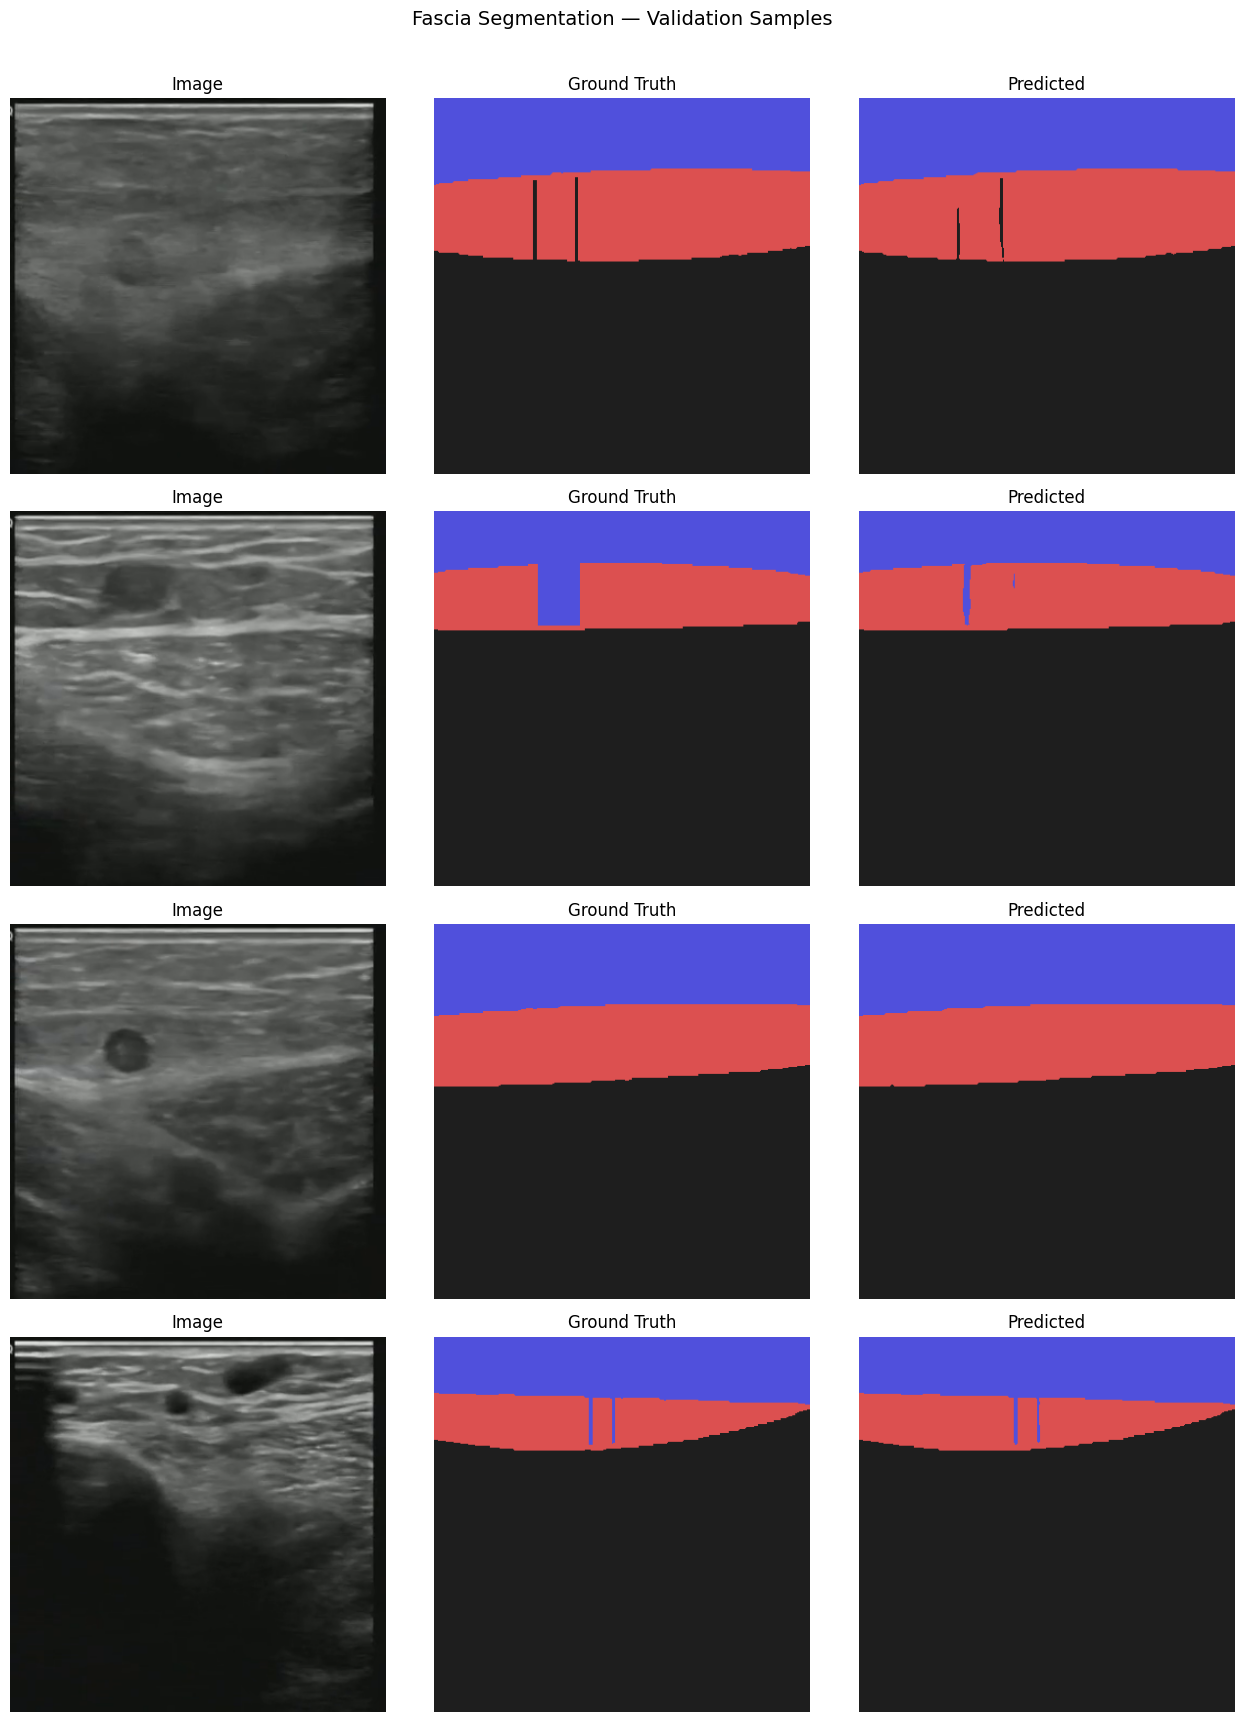

In [10]:
import matplotlib.pyplot as plt

PALETTE = np.array([[30,30,30],[220,80,80],[80,80,220]], dtype=np.uint8)

sample_rows = val_df.sample(4, random_state=7).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(13, 17))

for i, row in sample_rows.iterrows():
    img  = cv2.cvtColor(cv2.imread(row.frame_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
    img_r  = cv2.resize(img,  (384, 384))
    mask_r = cv2.resize(mask, (384, 384), interpolation=cv2.INTER_NEAREST)

    inp  = ((img_r.astype(np.float32)/255.0 - MEAN) / STD)[np.newaxis]
    pred = tf.argmax(best_model(inp, training=False), axis=-1).numpy()[0]

    axes[i][0].imshow(img_r);            axes[i][0].set_title('Image');      axes[i][0].axis('off')
    axes[i][1].imshow(PALETTE[mask_r]);  axes[i][1].set_title('Ground Truth'); axes[i][1].axis('off')
    axes[i][2].imshow(PALETTE[pred]);    axes[i][2].set_title('Predicted');  axes[i][2].axis('off')

plt.suptitle('Fascia Segmentation — Validation Samples', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output/fascia/predictions_sample.png', dpi=120, bbox_inches='tight')
plt.show()

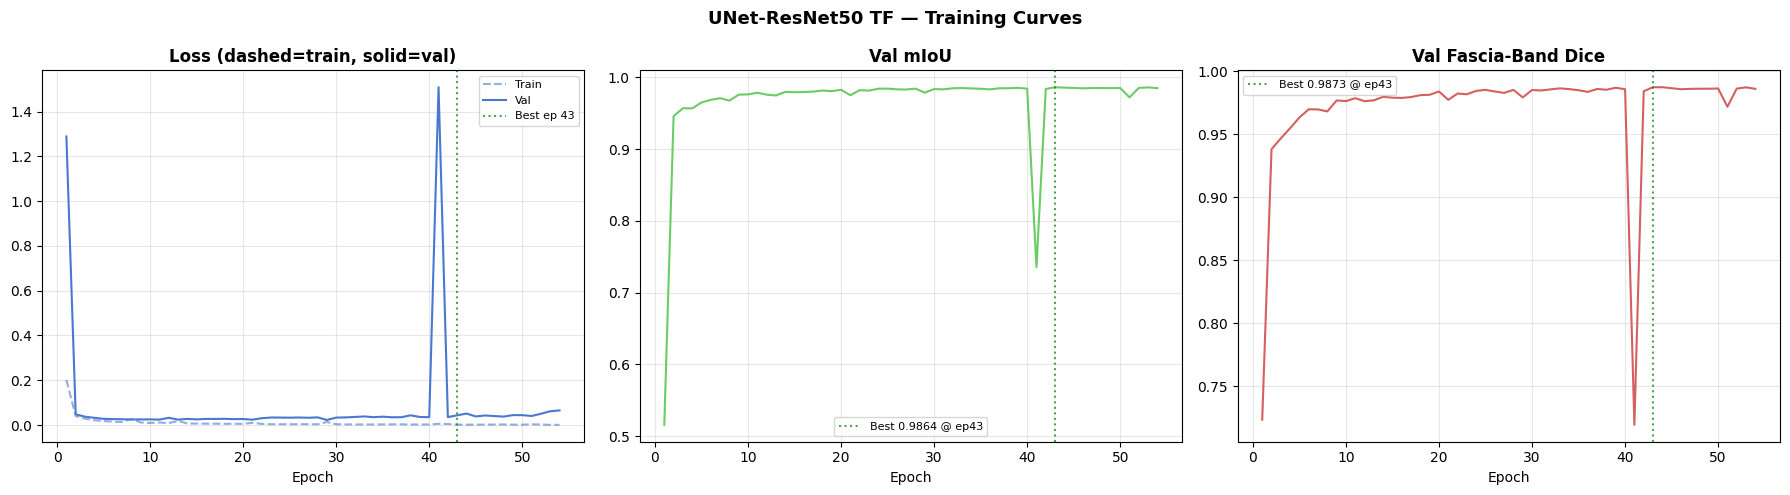

Best epoch: 43  |  Val mIoU: 0.9864  |  Val Fascia Dice: 0.9873


In [12]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = OUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Reconstructed from training log (epochs 1–54)
tr_loss = [0.2014,0.0398,0.0283,0.0212,0.0181,0.0148,0.0139,0.0277,0.0111,0.0094,
           0.0110,0.0086,0.0183,0.0069,0.0065,0.0061,0.0060,0.0056,0.0055,0.0052,
           0.0099,0.0050,0.0035,0.0034,0.0036,0.0035,0.0037,0.0032,0.0134,0.0036,
           0.0027,0.0025,0.0025,0.0025,0.0027,0.0031,0.0030,0.0022,0.0023,0.0024,
           0.0054,0.0044,0.0016,0.0015,0.0016,0.0019,0.0021,0.0025,0.0017,0.0016,
           0.0033,0.0021,0.000885,0.000784]

va_loss = [1.2888,0.0476,0.0372,0.0322,0.0276,0.0264,0.0258,0.0245,0.0250,0.0251,
           0.0241,0.0323,0.0240,0.0274,0.0251,0.0273,0.0272,0.0276,0.0263,0.0267,
           0.0239,0.0304,0.0335,0.0333,0.0328,0.0336,0.0324,0.0342,0.0225,0.0332,
           0.0340,0.0360,0.0384,0.0350,0.0371,0.0346,0.0348,0.0433,0.0359,0.0351,
           1.5088,0.0353,0.0433,0.0512,0.0383,0.0426,0.0400,0.0376,0.0443,0.0441,
           0.0403,0.0502,0.0614,0.0651]

va_miou = [0.5156,0.9460,0.9571,0.9569,0.9651,0.9688,0.9711,0.9677,0.9760,0.9764,
           0.9787,0.9760,0.9749,0.9798,0.9794,0.9797,0.9803,0.9818,0.9809,0.9828,
           0.9752,0.9823,0.9817,0.9843,0.9845,0.9834,0.9832,0.9844,0.9788,0.9838,
           0.9834,0.9849,0.9852,0.9847,0.9842,0.9834,0.9849,0.9850,0.9855,0.9844,
           0.7355,0.9839,0.9864,0.9858,0.9854,0.9848,0.9853,0.9852,0.9851,0.9853,
           0.9722,0.9855,0.9861,0.9851]

va_fdice = [0.7235,0.9381,0.9467,0.9548,0.9633,0.9698,0.9697,0.9681,0.9768,0.9763,
            0.9786,0.9762,0.9769,0.9797,0.9790,0.9788,0.9795,0.9810,0.9813,0.9839,
            0.9773,0.9823,0.9817,0.9844,0.9852,0.9839,0.9828,0.9852,0.9792,0.9851,
            0.9847,0.9856,0.9864,0.9858,0.9849,0.9836,0.9859,0.9853,0.9869,0.9857,
            0.7194,0.9841,0.9873,0.9873,0.9865,0.9857,0.9860,0.9861,0.9861,0.9863,
            0.9718,0.9862,0.9872,0.9860]

epochs = range(1, len(tr_loss) + 1)
best_ep = int(np.argmax(va_miou)) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UNet-ResNet50 TF — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(epochs, tr_loss, '--', color='#4878cf', alpha=0.6, label='Train')
axes[0].plot(epochs, va_loss, '-',  color='#4878cf', label='Val')
axes[0].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best ep {best_ep}')
axes[0].set_title('Loss (dashed=train, solid=val)', fontweight='bold')

axes[1].plot(epochs, va_miou, '-', color='#6acc65')
axes[1].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best {max(va_miou):.4f} @ ep{best_ep}')
axes[1].set_title('Val mIoU', fontweight='bold')

axes[2].plot(epochs, va_fdice, '-', color='#d65f5f')
axes[2].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best {va_fdice[best_ep-1]:.4f} @ ep{best_ep}')
axes[2].set_title('Val Fascia-Band Dice', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Best epoch: {best_ep}  |  Val mIoU: {max(va_miou):.4f}  |  Val Fascia Dice: {va_fdice[best_ep-1]:.4f}')

In [13]:
from scipy.ndimage import binary_erosion
import pandas as pd

def boundary_f1_np(pred, gt, cls=1, tolerance=2):
    p = (pred == cls).astype(np.uint8)
    t = (gt   == cls).astype(np.uint8)
    def get_boundary(mask):
        struct = np.ones((tolerance*2+1, tolerance*2+1), bool)
        eroded = binary_erosion(mask, struct).astype(np.uint8)
        return mask - eroded
    pb = get_boundary(p); tb = get_boundary(t)
    tp = np.sum(pb & tb)
    prec = tp / (np.sum(pb) + 1e-6)
    rec  = tp / (np.sum(tb) + 1e-6)
    return 2*prec*rec / (prec + rec + 1e-6)

# ── collect predictions ───────────────────────────────────────────────────────
all_preds, all_masks = [], []
for imgs, masks in val_ds:
    logits = best_model(imgs, training=False)
    all_preds.append(tf.argmax(logits, axis=-1).numpy())
    all_masks.append(masks.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_masks = np.concatenate(all_masks, axis=0)

# ── per-class IoU ─────────────────────────────────────────────────────────────
CLASS_NAMES = ['above', 'fascia', 'below']
ious, dices = {}, {}
for c, name in enumerate(CLASS_NAMES):
    inter = np.sum((all_preds == c) & (all_masks == c))
    union = np.sum((all_preds == c) | (all_masks == c))
    ious[f'iou_{name}'] = inter / (union + 1e-6)
    p = (all_preds == c).astype(np.float32)
    t = (all_masks == c).astype(np.float32)
    dices[f'dice_{name}'] = 2*np.sum(p*t) / (np.sum(p) + np.sum(t) + 1e-6)

miou = np.mean(list(ious.values()))

# ── boundary F1 on fascia band ────────────────────────────────────────────────
bf1_scores = [boundary_f1_np(all_preds[i], all_masks[i], cls=1)
              for i in range(len(all_preds))]

# ── table ─────────────────────────────────────────────────────────────────────
row = {
    'Model':       'UNet-ResNet50-TF',
    'mIoU':        round(miou, 4),
    'iou_fascia':  round(ious['iou_fascia'], 4),
    'dice_fascia': round(dices['dice_fascia'], 4),
    'boundary_f1': round(float(np.mean(bf1_scores)), 4),
    'iou_above':   round(ious['iou_above'], 4),
    'iou_below':   round(ious['iou_below'], 4),
}

results_df = pd.DataFrame([row]).set_index('Model')
results_df.to_csv(OUT_DIR / 'final_metrics.csv')

print('\n' + '='*70)
print('FINAL METRICS')
print('='*70)
print(results_df.to_string())


FINAL METRICS
                   mIoU  iou_fascia  dice_fascia  boundary_f1  iou_above  iou_below
Model                                                                              
UNet-ResNet50-TF  0.991      0.9826       0.9912       0.8469     0.9983     0.9921


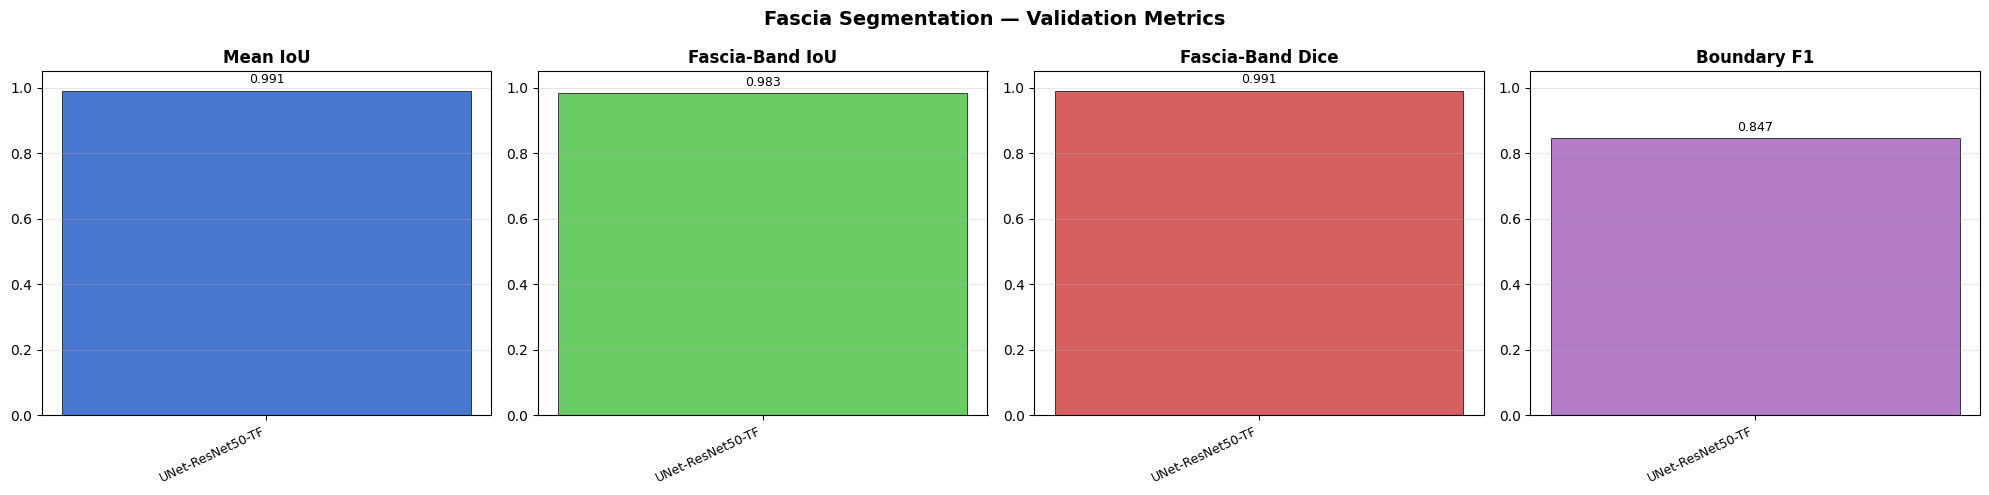

In [14]:
COLORS = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']
metrics_to_plot = ['mIoU', 'iou_fascia', 'dice_fascia', 'boundary_f1']
titles = ['Mean IoU', 'Fascia-Band IoU', 'Fascia-Band Dice', 'Boundary F1']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(results_df))

for ax, met, title, col in zip(axes, metrics_to_plot, titles, COLORS):
    vals = results_df[met].values
    bars = ax.bar(x, vals, color=col, edgecolor='k', linewidth=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index, rotation=25, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fascia Segmentation — Validation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'metrics_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

Best model: UNet-ResNet50-TF  (mIoU = 0.9910)


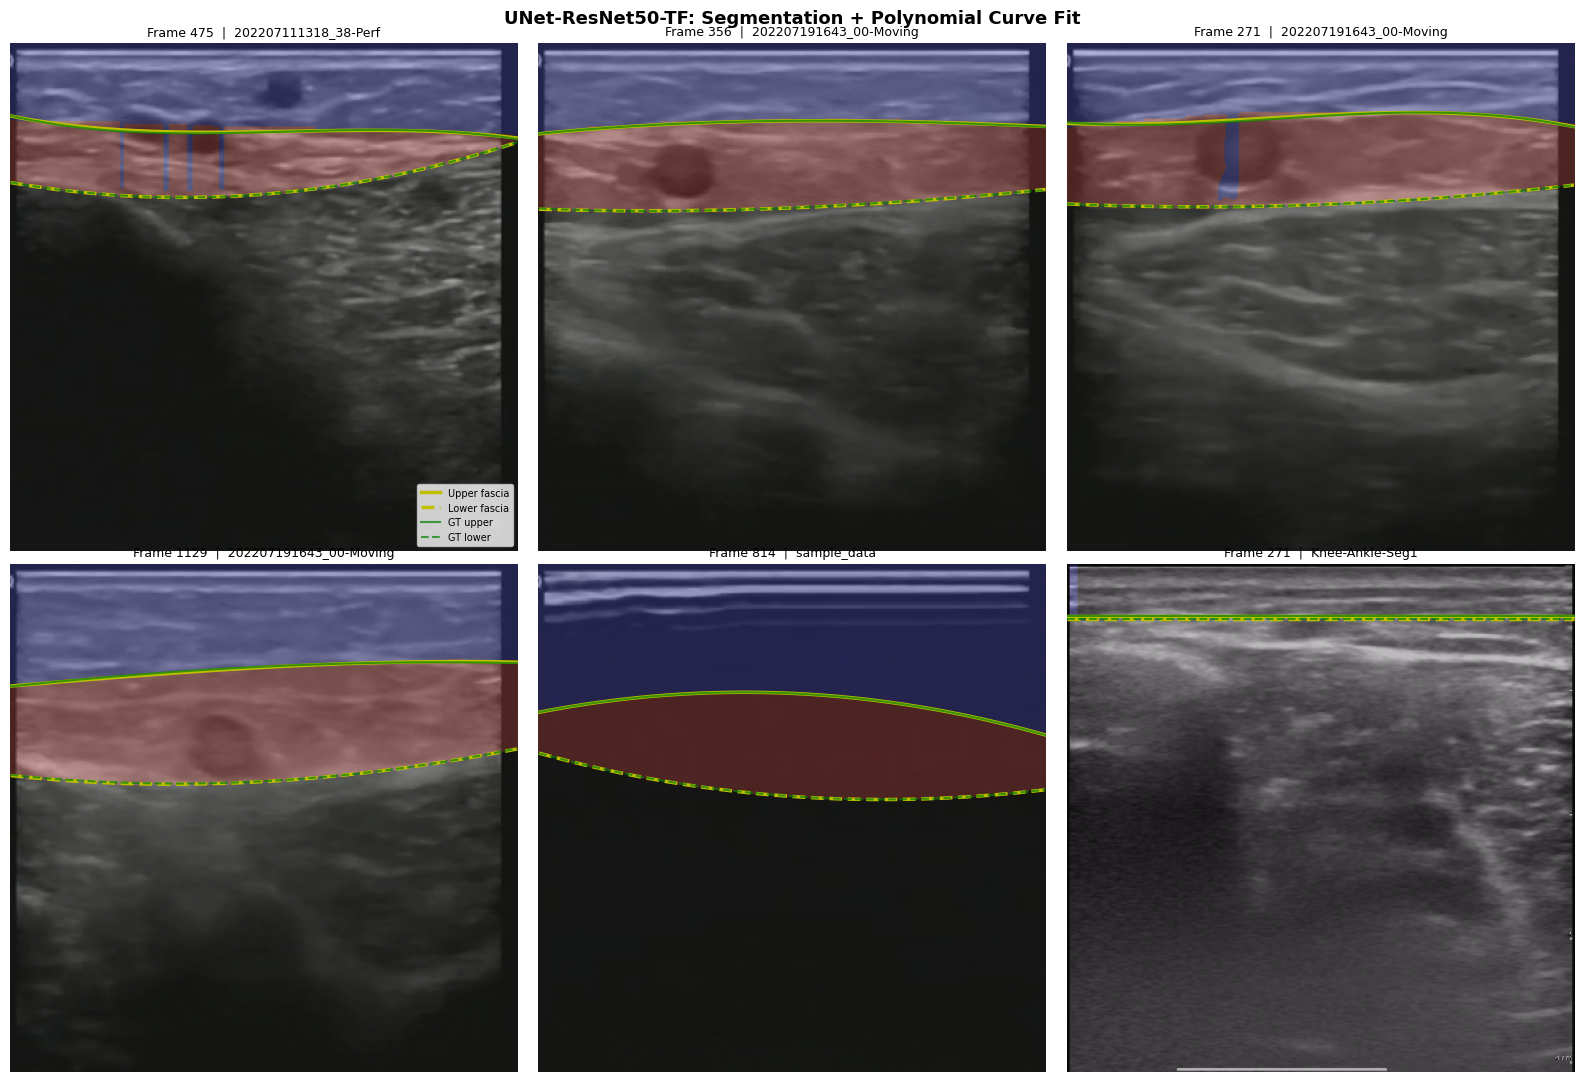

In [15]:
from numpy.polynomial import polynomial as P

def extract_fascia_curves(seg_mask, poly_degree=3):
    band  = (seg_mask == 1).astype(np.uint8)
    h, w  = band.shape
    xs, y_tops, y_bots = [], [], []
    for x in range(w):
        ys = np.where(band[:, x] > 0)[0]
        if len(ys) >= 2:
            xs.append(x); y_tops.append(ys.min()); y_bots.append(ys.max())
    if len(xs) < poly_degree + 1:
        return None, None, None
    xs = np.array(xs, float); xs_norm = xs / w
    coeff_top = np.polyfit(xs_norm, y_tops, poly_degree)
    coeff_bot = np.polyfit(xs_norm, y_bots, poly_degree)
    x_all = np.arange(w, dtype=float); x_norm = x_all / w
    return x_all, np.polyval(coeff_top, x_norm), np.polyval(coeff_bot, x_norm)


PALETTE = np.array([[30,30,30],[220,80,80],[80,80,220]], dtype=np.uint8)

print(f'Best model: UNet-ResNet50-TF  (mIoU = {results_df["mIoU"].values[0]:.4f})')

val_valid = val_df.reset_index(drop=True)
n_show    = min(6, len(val_valid))
idxs      = np.linspace(0, len(val_valid)-1, n_show, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

for i, idx in enumerate(idxs):
    row   = val_valid.iloc[idx]
    img   = cv2.cvtColor(cv2.imread(row.frame_path), cv2.COLOR_BGR2RGB)
    gt    = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
    img_r = cv2.resize(img,  (384, 384))
    gt_r  = cv2.resize(gt,   (384, 384), interpolation=cv2.INTER_NEAREST)

    inp  = ((img_r.astype(np.float32)/255.0 - MEAN) / STD)[np.newaxis]
    pred = tf.argmax(best_model(inp, training=False), axis=-1).numpy()[0].astype(np.uint8)

    x_pts, y_up, y_lo = extract_fascia_curves(pred)
    xg,    yu_g, yl_g = extract_fascia_curves(gt_r)

    axes[i].imshow(img_r)
    axes[i].imshow(PALETTE[pred], alpha=0.30)
    if x_pts is not None:
        axes[i].plot(x_pts, y_up, 'y-',  lw=2.5, label='Upper fascia')
        axes[i].plot(x_pts, y_lo, 'y--', lw=2.5, label='Lower fascia')
    if xg is not None:
        axes[i].plot(xg, yu_g, 'g-',  lw=1.5, alpha=0.7, label='GT upper')
        axes[i].plot(xg, yl_g, 'g--', lw=1.5, alpha=0.7, label='GT lower')

    axes[i].set_title(f'Frame {row.frame_idx}  |  {row.video}', fontsize=9)
    axes[i].axis('off')
    if i == 0:
        axes[i].legend(fontsize=7, loc='lower right')

plt.suptitle('UNet-ResNet50-TF: Segmentation + Polynomial Curve Fit',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'best_model_curves.png', dpi=130, bbox_inches='tight')
plt.show()

In [17]:
print('=' * 65)
print('FASCIA DETECTION — FINAL SUMMARY')
print('=' * 65)
print(results_df[['mIoU','iou_fascia','dice_fascia','boundary_f1']]
      .sort_values('mIoU', ascending=False).to_string())
print()
best = results_df.index[0]
print(f'Winner : {best}')
print(f'  mIoU           : {results_df.loc[best,"mIoU"]:.4f}')
print(f'  Fascia-band IoU: {results_df.loc[best,"iou_fascia"]:.4f}')
print(f'  Fascia Dice    : {results_df.loc[best,"dice_fascia"]:.4f}')
print(f'  Boundary F1    : {results_df.loc[best,"boundary_f1"]:.4f}')
print()
print(f'Best checkpoint : {CKPT_DIR / "unet_resnet50_tf_best.keras"}')
print(f'All plots saved : {PLOT_DIR.resolve()}')

FASCIA DETECTION — FINAL SUMMARY
                   mIoU  iou_fascia  dice_fascia  boundary_f1
Model                                                        
UNet-ResNet50-TF  0.991      0.9826       0.9912       0.8469

Winner : UNet-ResNet50-TF
  mIoU           : 0.9910
  Fascia-band IoU: 0.9826
  Fascia Dice    : 0.9912
  Boundary F1    : 0.8469

Best checkpoint : output/fascia/checkpoints/unet_resnet50_tf_best.keras
All plots saved : /home/krish/vein_detection_task_3_training/output/fascia/plots
